# **Capstone Project 2**

**Amazon SaaS Sales Data Analysis**

`Muhammad Alif Hidayah (JCDS 3004 - 011)`

# **Profil Perusahaan**
AWS (Amazon Web Service) merupakan bagian dari Amazon yang berfokus pada penyediaan layanan cloud computing terlengkap dan paling banyak digunakan di dunia. Salah satu layanan utama yang ditawarkan AWS adalah model Software as a Service (SaaS), di mana AWS menyediakan solusi perangkat lunak berbasis cloud yang dapat diakses oleh pelanggan bisnis (B2B) tanpa perlu infrastruktur fisik maupun instalasi lokal.

Dengan basis pelanggan yang sangat luas, AWS SaaS melayani berbagai sektor industri, mulai dari keuangan, ritel, manufaktur, hingga sektor publik dan startup digital. Setiap sektor memiliki kebutuhan yang berbeda-beda, sehingga AWS menyediakan paket solusi yang dapat disesuaikan (customizable) sesuai kebutuhan spesifik industri maupun skala bisnis.

## **Pernyataan Masalah Bisnis**

AWS (Amazon Web Service) merupakan perusahaan penyedia layanan SaaS yang menawarkan perangkat lunak untuk penjualan dan pemasaran kepada pelanggan bisnis (B2B). Perusahaan ini telah mengumpulkan data transaksi dari para pelanggannya.

Masalah yang ingin diselesaikan dalam analisis ini adalah:

1. **Menganalisis performa penjualan perusahaan**, termasuk mengidentifikasi faktor utama yang memengaruhi penjualan dan profitabilitas, khususnya pada produk yang mencatatkan keuntungan negatif. Hal ini meliputi analisis dampak diskon terhadap penjualan, perbandingan performa antar produk, serta pola penjualan dalam periode waktu tertentu. 

2. **Menganalisis kondisi pasar perusahaan**, termasuk menentukan wilayah atau sub-wilayah mana yang menghasilkan performa terbaik serta memahami bagaimana pelanggan tersebar di berbagai sektor industri.

AWS ingin memahami lebih jauh mengenai penyebab di balik profitabilitas negatif pada produk SaaS yang mereka jual, terutama terkait produk-produk yang tidak menguntungkan. Oleh karena itu, tujuan analisis ini adalah untuk menemukan faktor atau variabel yang menyebabkan rendahnya profitabilitas dengan mengevaluasi performa penjualan, dan kondisi pasar perusahaan. Sebagai seorang analis data, saya akan menjawab pertanyaan berikut:

*"Bagaimana cara menganalisis faktor-faktor yang menyebabkan rendahnya profitabilitas produk SaaS AWS, serta memberikan rekomendasi praktis untuk memperbaiki profitabilitas produk-produk tersebut berdasarkan hasil analisis performa penjualan, dan kondisi pasar perusahaan?"*

Untuk menjawab pertanyaan masalah tersebut saya melakukan penambahan kolom profit margin, dan analisis produk-produk yang mengalami profit negatif. Kemudian dianalisis pengaruh diskon terhadap profit serta dilakukan visualisasi untuk membandingkan performa antar produk dan menganalisis tren waktu penjualan,serta dilakukan analisis wilayah termasuk pemetaan sebaran pelanggan dan identifikasi wilayah atau sektor yang berkontribusi terhadap profit negatif. Seluruh analisis didukung oleh visualisasi data dan komparasi statistik.

## **Tujuan**

Tujuan utama analisis ini adalah memberikan insight yang berguna bagi perusahaan AWS agar mereka dapat memahami dan meningkatkan kinerja bisnisnya, khususnya untuk mengatasi masalah profitabilitas negatif. Dengan melakukan kedua analisis tersebut, AWS dapat mengambil keputusan yang lebih akurat guna meningkatkan penjualan, memperbaiki layanan kepada pelanggan, serta memperluas cakupan pasar. Pada akhirnya, hal ini akan mendorong peningkatan profitabilitas sekaligus mendukung pertumbuhan perusahaan secara berkelanjutan.

## **Dataset**
Dataset ini berisi data penjualan produk Software as a Service (SaaS) dari sebuah perusahaan yang beroperasi di berbagai negara dan wilayah. Data ini dikumpulkan untuk mendukung analisis performa bisnis, khususnya dalam mengidentifikasi pola penjualan, profit, serta faktor-faktor yang mempengaruhi keberhasilan dan tantangan dalam penjualan produk SaaS.

Untuk menjawab pertanyaan di atas, kita akan menganalisa data peserta yang sudah dikumpulkan oleh perusahaan. Dataset dapat diakses [di sini](https://drive.google.com/drive/folders/1dlpJfgvs8P_IyXqWB4WrNwk91fx0XAzU).


# **Data Preparation & Load Dataset**

Dataset ini berisi data transaksi dari perusahaan SaaS (Software as a Service) yang menjual perangkat lunak penjualan dan pemasaran kepada perusahaan lain (B2B). Dalam dataset, setiap baris mewakili satu transaksi/pesanan (9.994 transaksi), dan kolom-kolomnya meliputi:

**Deskripsi Kolom**

**Berikut adalah dataset asli:**

| **Nama Kolom**   | **Dekskripsi Kolom**                              |
| ---------------- | -------------------------------------------------------- |
| **Row ID**       | Pengidentifikasi unik untuk setiap transaksi             |
| **Order ID**     | Pengidentifikasi unik untuk setiap pesanan.              |
| **Order Date**   | Tanggal pesanan ditempatkan.                             |
| **Date Key**     | Representasi numerik dari tanggal pesanan (YYYYMMDD).    |
| **Contact Name** | Nama orang yang menempatkan pesanan.                     |
| **Country**      | Negara tempat pesanan ditempatkan.                       |
| **City**         | Kota tempat pesanan ditempatkan.                         |
| **Region**       | Wilayah tempat pesanan ditempatkan.                      |
| **Subregion**    | Subwilayah tempat pesanan ditempatkan.                   |
| **Customer**     | Nama perusahaan yang menempatkan pesanan.                |
| **Customer ID**  | Pengidentifikasi unik untuk setiap pelanggan.            |
| **Industry**     | Industri tempat pelanggan berasal.                       |
| **Segment**      | Segmen pelanggan (SMB, Strategic, Enterprise, dll.).     |
| **Product**      | Produk yang dipesan.                                     |
| **License**      | Kunci lisensi untuk produk.                              |
| **Sales**        | Jumlah total penjualan untuk transaksi.                  |
| **Quantity**     | Jumlah total item dalam transaksi.                       |
| **Discount**     | Diskon yang diterapkan pada transaksi.                   |
| **Profit**       | Keuntungan dari transaksi.                               |


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import scipy.stats as stats

In [2]:
# Import Dataset
df = pd.read_csv('/Users/malifhdyh/Downloads/Purwadhika/Capstone/Capstone 2/SaaS Sales Data.csv', 
                 parse_dates=['Order Date'],    # Change all date format from object to Datetime64[ns]
                 dtype= {'Customer ID': str})   # Change ID format because contains of Alphanumeric
df = df.drop(columns=['Row ID','Date Key'])
# View the top and bottom 5 rows of data
display(df.head(), df.tail())

df_coords = pd.read_csv('Country_Coordinates.csv')

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,AMER-2022-138688,2022-06-13,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
9989,EMEA-2020-110422,2020-01-22,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,SMB,SaaS Connector Pack,ETHXMB5TMD,25.248,3,0.2,4.1028
9990,AMER-2023-121258,2023-02-27,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,SaaS Connector Pack,LYHOKTRY7L,91.960,2,0.0,15.6332
9991,AMER-2023-121258,2023-02-27,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Site Analytics,I5SVMI6M88,258.576,2,0.2,19.3932
9992,AMER-2023-121258,2023-02-27,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Support,JHLW4P6LQ2,29.600,4,0.0,13.3200
9993,AMER-2023-119914,2023-05-05,Jasmine Springer,United States,Dallas,AMER,NAMER,Comcast,1022,Communications,SMB,OneView,3NTBV9B3PS,243.160,2,0.0,72.9480


## Mengubah Tipe Data dan Menghapus Kolom Row ID & Date Key

**Kenapa saya melakukan perubahan ini?**

1. Kolom 'Order Date' diubah ke format tanggal (pakai `parse_dates='Order Date'`)

- Supaya data tanggal bisa langsung dipakai untuk analisis tren, filter data berdasarkan waktu, atau visualisasi yang butuh format tanggal. Jadi, lebih gampang kalau mau olah data berdasarkan waktu.

2. Kolom 'Customer ID' diubah ke tipe string (pakai `dtype='Customer ID': str`)

- Karena ID pelanggan kadang berupa kombinasi huruf dan angka, atau ada angka nol di depannya. Dengan tipe string, data ID tetap aman dan tidak berubah.

3. Kolom 'Row ID' dan 'Date Key' dihapus karena tidak dibutuhkan

- 'Row ID' cuma nomor urut, sama saja dengan index di DataFrame, jadi tidak perlu.
- 'Date Key' sebenarnya sama saja dengan 'Order Date', cuma beda format (angka vs tanggal). Karena sudah ada 'Order Date', kolom ini jadi tidak penting untuk analisis.


#  **Data Understanding and Data Cleaning**
Langkah pertama yang dilakukan adalah pemahaman data dan pembersihan data. Hal ini diperlukan untuk memahami isi dataset, serta mendeteksi jika terdapat kesalahan atau kerusakan pada data agar hasil analisis menjadi maksimal.

A) Pemahaman Data, Identifikasi Duplikasi, dan Pemeriksaan Format Data

Mengenali informasi kolom dan baris dari dataset, memeriksa adanya data duplikat dan format data, serta menghapus kolom yang tidak relevan.

In [3]:
# To view the rows and column in df dataset

a,b = df.shape
print(f'Dalam dataset ini terdapat {a} baris dan {b} kolom')

Dalam dataset ini terdapat 9994 baris dan 17 kolom


## **Menambahkan Kolom Profit Margin**

Menambahkan kolom profit margin membantu kita memahami seberapa besar keuntungan yang diperoleh perusahaan dibandingkan dengan penjualannya. Ini menunjukkan seberapa efisien perusahaan mengubah penjualan menjadi profit. Informasi ini membantu kita memantau kondisi keuangan perusahaan dan menentukan area mana yang perlu difokuskan untuk meningkatkan keuntungan.


In [4]:
df["Profit Margin"] = round((df["Profit"] / df["Sales"]) * 100, 2)

# Display the updated DataFrame
df.head()

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Profit Margin
0,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,16.00
1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820,30.00
2,AMER-2022-138688,2022-06-13,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714,47.00
3,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310,-40.00
4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164,11.25


In [5]:
# To see the information about this dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Order Date     9994 non-null   datetime64[ns]
 2   Contact Name   9994 non-null   object        
 3   Country        9994 non-null   object        
 4   City           9994 non-null   object        
 5   Region         9994 non-null   object        
 6   Subregion      9994 non-null   object        
 7   Customer       9994 non-null   object        
 8   Customer ID    9994 non-null   object        
 9   Industry       9994 non-null   object        
 10  Segment        9994 non-null   object        
 11  Product        9994 non-null   object        
 12  License        9994 non-null   object        
 13  Sales          9994 non-null   float64       
 14  Quantity       9994 non-null   int64         
 15  Discount       9994 n

**Dari informasi ini, kita dapat melihat bahwa setiap kolom sudah berada pada Tipe Data yang tepat:**

**1. Tipe Data Object:** Kolom seperti 'Order ID', 'Contact Name', 'Country', 'City', 'Region', 'Subregion', 'Customer', 'Customer ID', 'Industry', 'Segment', 'Product', dan 'License' bertipe data 'object', yang biasanya menandakan data kategorikal atau string. Kolom-kolom ini kemungkinan berisi informasi teks atau kategori, sehingga sudah tepat disimpan sebagai tipe object.

**- Kita perlu mengubah Customer ID dari integer menjadi Object.**

**2. Tipe Data Datetime:** Kolom 'Order Date' bertipe 'datetime64[ns]', yang sangat ideal untuk menangani data tanggal dan waktu. Tipe data ini memudahkan manipulasi dan analisis informasi temporal, seperti tren pemesanan dari waktu ke waktu, agregasi berbasis waktu, atau operasi filter berdasarkan tanggal.

**- Kita perlu mengubah Order Date dari Integer menjadi Datetime**

**3. Tipe Data Numerik:** Kolom seperti 'Sales', 'Quantity', 'Discount', dan 'Profit' bertipe 'float64' (untuk nilai numerik kontinu) atau 'int64' (untuk nilai numerik diskrit).  
Tipe data ini sesuai untuk kolom yang berisi informasi numerik seperti jumlah penjualan, kuantitas, diskon, dan profit.

**Kesimpulan**  
Jika semua kolom sudah diklasifikasikan dengan tipe data yang sesuai, maka operasi dan analisis yang dilakukan pada kolom-kolom tersebut akan tepat dan mencerminkan karakteristik data yang dimiliki.


## Data Statistic Descriptive

In [6]:
# To show each column statistic descriptive
display(df.describe(), df.describe(include='object'))

,Order Date,Sales,Quantity,Discount,Profit,Profit Margin
count,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,2022-05-01 00:07:12.259355648,229.858001,3.789574,0.156203,28.656896,12.031390
min,2020-01-04 00:00:00,0.444000,1.000000,0.000000,-6599.978000,-275.000000
25%,2021-05-23 00:00:00,17.280000,2.000000,0.000000,1.728750,7.500000
50%,2022-06-27 00:00:00,54.490000,3.000000,0.200000,8.666500,27.000000
75%,2023-05-15 00:00:00,209.940000,5.000000,0.200000,29.364000,36.250000
max,2023-12-31 00:00:00,22638.480000,14.000000,0.800000,8399.976000,50.000000
std,NaN,623.245101,2.225110,0.206452,234.260108,46.675436


,Order ID,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,793,48,262,3,12,99,99,10,3,14,9994
top,EMEA-2023-100111,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,1080,Finance,SMB,ContactMatcher,16GRM07R1K
freq,14,37,2001,922,4219,2507,192,192,2127,5191,1842,1


## Memeriksa Nilai Unik pada Setiap Kolom
Memeriksa nilai unik di setiap kolom membantu kita memahami keragaman data, mendeteksi kemungkinan duplikasi, serta mengenali kategori atau entitas yang ada dalam dataset. Langkah ini penting untuk analisis eksplorasi data dan memastikan kualitas data sebelum melakukan analisis lebih lanjut.

In [7]:
# Check Unique Values exist in dataset
# To show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) 

def unique_data(df):
    
    data_unique = pd.DataFrame()
    data_unique['Columns'] = df.columns
    data_unique['Unique Count'] = [df[col].nunique() for col in (df.columns)]
    data_unique['Unique'] = [df[col].unique() for col in (df.columns)] 
    return data_unique

unique_data(df)

,Columns,Unique Count,Unique
0,Order ID,5009,"[EMEA-2022-152156, AMER-2022-138688, EMEA-2021-108966, AMER-2020-115812, EMEA-2023-114412, AMER-2022-161389, APJ-2021-118983, EMEA-2020-105893, EMEA-2020-167164, AMER-2020-143336, AMER-2022-137330, EMEA-2023-156909, EMEA-2021-106320, AMER-2022-121755, EMEA-2021-150630, APJ-2023-107727, APJ-2022-117590, APJ-2021-117415, APJ-2023-120999, AMER-2022-101343, EMEA-2023-139619, EMEA-2022-118255, AMER-2020-146703, APJ-2022-169194, APJ-2021-115742, EMEA-2022-105816, EMEA-2022-111682, AMER-2021-135545, APJ-2021-164175, AMER-2020-106376, EMEA-2022-119823, EMEA-2022-106075, AMER-2023-114440, EMEA-2021-134026, APJ-2023-118038, APJ-2020-147606, EMEA-2022-127208, AMER-2020-139451, EMEA-2021-149734, APJ-2023-119662, AMER-2023-140088, EMEA-2023-155558, APJ-2022-159695, AMER-2022-109806, EMEA-2021-149587, EMEA-2023-109484, EMEA-2023-161018, AMER-2023-157833, EMEA-2022-149223, APJ-2022-158568, EMEA-2022-129903, EMEA-2021-156867, EMEA-2023-119004, APJ-2021-129476, EMEA-2023-146780, EMEA-2022-128867, AMER-2020-115259, AMER-2021-110457, EMEA-2021-136476, APJ-2022-103730, APJ-2020-152030, APJ-2020-134614, AMER-2023-107272, AMER-2022-125969, AMER-2023-164147, AMER-2022-145583, EMEA-2022-110366, AMER-2023-106180, EMEA-2023-155376, AMER-2021-110744, AMER-2020-110072, EMEA-2022-114489, AMER-2022-158834, AMER-2021-124919, AMER-2021-118948, AMER-2020-104269, APJ-2022-114104, AMER-2022-162733, EMEA-2021-119697, APJ-2022-154508, AMER-2022-113817, APJ-2020-139892, AMER-2020-118962, APJ-2020-100853, APJ-2023-152366, AMER-2021-101511, EMEA-2021-137225, APJ-2020-166191, EMEA-2020-158274, EMEA-2022-105018, AMER-2020-123260, APJ-2022-157000, EMEA-2021-102281, AMER-2021-131457, AMER-2020-140004, AMER-2023-107720, EMEA-2023-124303, AMER-2023-105074, EMEA-2020-133690, APJ-2023-116701, ...]"
1,Order Date,1237,"[2022-11-09 00:00:00, 2022-06-13 00:00:00, 2021-10-11 00:00:00, 2020-06-09 00:00:00, 2023-04-16 00:00:00, 2022-12-06 00:00:00, 2021-11-22 00:00:00, 2020-11-11 00:00:00, 2020-05-13 00:00:00, 2020-08-27 00:00:00, 2022-12-10 00:00:00, 2023-07-17 00:00:00, 2021-09-25 00:00:00, 2022-01-16 00:00:00, 2021-09-17 00:00:00, 2023-10-20 00:00:00, 2022-12-09 00:00:00, 2021-12-27 00:00:00, 2023-09-11 00:00:00, 2022-07-18 00:00:00, 2023-09-20 00:00:00, 2022-03-12 00:00:00, 2020-10-20 00:00:00, 2022-06-21 00:00:00, 2021-04-18 00:00:00, 2022-12-12 00:00:00, 2022-06-18 00:00:00, 2021-11-24 00:00:00, 2021-04-30 00:00:00, 2020-12-05 00:00:00, 2022-06-05 00:00:00, 2022-09-19 00:00:00, 2023-09-15 00:00:00, 2021-04-26 00:00:00, 2023-12-10 00:00:00, 2020-11-26 00:00:00, 2020-10-12 00:00:00, 2021-09-03 00:00:00, 2023-11-14 00:00:00, 2023-05-29 00:00:00, 2023-10-27 00:00:00, 2022-04-06 00:00:00, 2022-09-18 00:00:00, 2021-01-31 00:00:00, 2023-11-07 00:00:00, 2023-11-10 00:00:00, 2023-06-18 00:00:00, 2022-09-07 00:00:00, 2022-08-30 00:00:00, 2022-12-02 00:00:00, 2021-11-13 00:00:00, 2023-11-24 00:00:00, 2021-10-15 00:00:00, 2023-12-26 00:00:00, 2022-11-04 00:00:00, 2020-08-25 00:00:00, 2021-03-02 00:00:00, 2021-04-05 00:00:00, 2020-12-26 00:00:00, 2020-09-20 00:00:00, 2023-11-06 00:00:00, 2022-11-07 00:00:00, 2023-02-03 00:00:00, 2022-10-14 00:00:00, 2022-09-06 00:00:00, 2023-09-19 00:00:00, 2023-12-23 00:00:00, 2021-09-07 00:00:00, 2020-10-22 00:00:00, 2022-03-14 00:00:00, 2021-05-31 00:00:00, 2021-05-28 00:00:00, 2020-03-01 00:00:00, 2022-11-21 00:00:00, 2022-05-12 00:00:00, 2021-12-28 00:00:00, 2022-11-17 00:00:00, 2022-11-08 00:00:00, 2020-09-08 00:00:00, 2020-08-05 00:00:00, 2020-09-14 00:00:00, 2023-04-22 00:00:00, 2021-11-21 00:00:00, 2021-12-15 00:00:00, 2020-11-19 00:00:00, 2022-11-29 00:00:00, 2020-08-26 00:00:00, 2022-07-17 00:00:00, 2021-10-12 00:00:00, 2021-10-31 00:00:00, 2020-03-21 00:00:00, 2023-07-07 00:00:00, 2023-06-25 00:00:00, 2020-08-03 00:00:00, 2023-12-18 00:00:00, 2023-06-04 00:00:00, 2023-12-02 00:00:00, 2021-02-09 00:00:00, 2021-01-02 00:00:00, 2022-10-29 00:00:00, ...]"
2,Contact Name,793,"[Nathan Bell, Deirdre Bail

## Insight dari Nilai Unik Setiap Kolom

**1. Order ID:** Terdapat 5009 Order ID unik. ID ini tampaknya memiliki pola berdasarkan region (EMEA, AMER, APJ) dan terdapat penanda tahun pada ID tersebut untuk menunjukkan kapan pesanan dilakukan.

**2. Order Date:** Terdapat 1237 tanggal pesanan unik, menunjukkan bahwa dataset mencakup rentang waktu dari 2020-01-04 hingga 2023-12-31.

**3. Contact Name:** Terdapat 793 nama kontak unik, menandakan keterlibatan beragam individu dalam pemesanan.

**4. Country & City:** Terdapat 48 negara unik dan 262 kota unik, mencerminkan distribusi geografis pelanggan yang luas.

**5. Region & Subregion:** Terdapat 3 region unik dan 12 subregion, yang kemungkinan merepresentasikan klasifikasi geografis di dalam region tersebut.

**6. Customer & Customer ID:** Terdapat 99 pelanggan unik beserta Customer ID yang sesuai, menandakan basis pelanggan yang beragam dan setiap pelanggan memiliki Customer ID yang unik.

**7. Industry & Segment:** Terdapat 10 industri unik dan 3 segmen unik, menunjukkan variasi industri dan segmen pelanggan dalam dataset.

**8. Product & License:** Terdapat 14 produk unik dan 9994 kode lisensi unik. Hal ini menunjukkan adanya kumpulan produk tetap dengan kode lisensi yang bervariasi.

**9. Sales, Quantity, Discount, Profit:** Kolom-kolom ini berisi berbagai nilai numerik dengan rentang yang berbeda-beda, menandakan variasi jumlah penjualan, kuantitas pesanan, tingkat diskon yang diterapkan, dan profit yang dihasilkan di seluruh dataset.


## **Beberapa Pertimbangan untuk Analisis Lanjutan**

**1. Order ID:** Perlu dipertimbangkan lebih lanjut jika terdapat ID yang tidak mengikuti pola standar atau terdapat duplikasi, yang dapat mengindikasikan kesalahan dalam entri atau pemrosesan data.

**2. Order Date:** Perlu dipertimbangkan lebih lanjut jika terdapat tanggal di luar rentang waktu yang diharapkan atau jika terdapat banyak pesanan pada tanggal tertentu, yang dapat mengindikasikan kesalahan atau hari penjualan yang tidak biasa.

**3. Sales, Quantity, Discount, Profit:** Perlu dipertimbangkan lebih lanjut pada kolom numerik ini jika terdapat nilai yang sangat tinggi atau sangat rendah dibandingkan dengan rentang biasanya, yang mungkin menandakan kesalahan entri data, outlier, atau kejadian signifikan yang memengaruhi penjualan.

**4. Customer & Customer ID:** Perlu dipertimbangkan lebih lanjut jika ada pelanggan dengan jumlah pesanan yang sangat tinggi atau sangat rendah dibandingkan yang lain, atau jika terdapat inkonsistensi pada Customer ID.

**5. Country & City:** Perlu dipertimbangkan lebih lanjut pada kolom ini jika terdapat kota atau negara yang tidak sesuai dengan region yang diharapkan dalam dataset, atau jika ada kota tertentu dengan jumlah pesanan yang sangat tinggi secara tidak wajar.


## Memeriksa Apakah Ada Missing Value


In [8]:
print('Missing values status:', df.isnull().values.any())
missing_values = pd.DataFrame(df.isnull().sum(), columns=['Total Null Values'])
missing_values['Percentage'] = (missing_values['Total Null Values'] / df.shape[0]) * 100
missing_values.sort_values(by='Percentage', ascending=False).reset_index()

Missing values status: False


,index,Total Null Values,Percentage
0,Order ID,0,0.0
1,Order Date,0,0.0
2,Profit,0,0.0
3,Discount,0,0.0
4,Quantity,0,0.0
5,Sales,0,0.0
6,License,0,0.0
7,Product,0,0.0
8,Segment,0,0.0
9,Industry,0,0.0


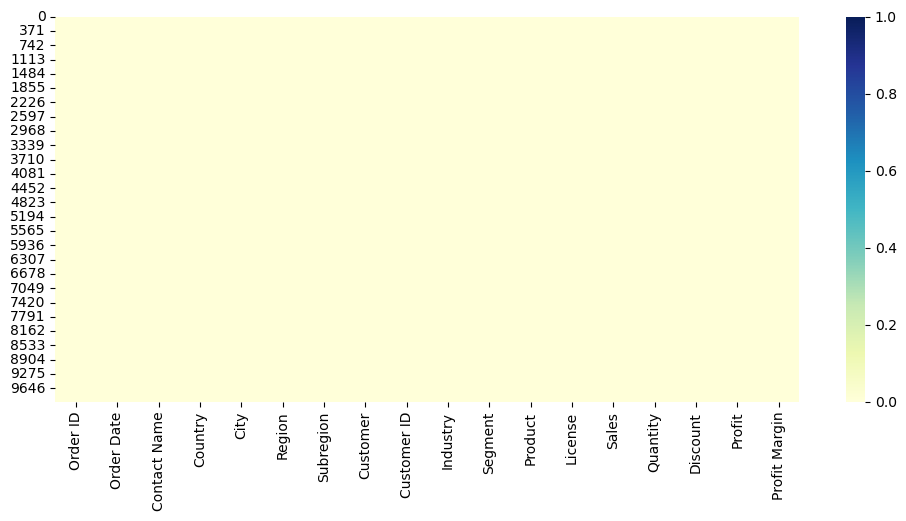

In [9]:
plt.figure(figsize=(12, 5))
sns.heatmap(data=df.isna(), vmin=0, vmax=1, cmap="YlGnBu")
plt.show()

**Dataset AWS SaaS-Sales ini tidak memiliki nilai yang hilang pada setiap kolomnya**

- Tidak perlu melakukan penanganan missing value pada dataset ini. Hal ini dapat terlihat dengan jelas pada kedua output di atas yang menunjukkan angka 0 (nol) pada setiap kolom, serta pada heatmap yang secara keseluruhan tampak terang pada setiap baris dan kolom, tanpa adanya garis gelap yang menandakan keberadaan missing value.


## Memeriksa Apakah Ada Data Duplikat

Memastikan tidak ada data duplikat sangat penting agar analisis yang dilakukan akurat dan tidak bias. Data duplikat dapat menyebabkan hasil analisis menjadi tidak valid karena satu transaksi bisa dihitung lebih dari sekali. Oleh karena itu, sebelum melanjutkan ke tahap analisis berikutnya, kita perlu memeriksa apakah terdapat baris data yang sama persis (duplikat) dalam dataset. Jika ditemukan, data duplikat tersebut harus dihapus agar hasil analisis lebih representatif.


In [10]:
df[df.duplicated(keep=False)]

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Profit Margin


In [11]:
df[df['Order ID'].duplicated(keep=False)].head()

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Profit Margin
0,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,16.00
1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820,30.00
3,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310,-40.00
4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164,11.25
5,AMER-2020-115812,2020-06-09,Thomas Hodges,United States,New York City,AMER,NAMER,BNP Paribas,1065,Finance,SMB,SaaS Connector Pack,8RM88WFOAE,48.8600,7,0.00,14.1694,29.00


Untuk memastikan tidak ada data duplikat pada setiap baris, kita dapat menggunakan Order ID yang seharusnya unik. Dari data ini, tidak ditemukan Order ID yang duplikat.


## Memeriksa Apakah Ada Outlier

**a). Menggunakan Boxplot untuk Melihat Berapa Banyak Outlier yang Ditemukan dalam Dataset Ini**

Outlier adalah data yang nilainya sangat berbeda jauh dari data observasi lainnya. Outlier dapat memengaruhi hasil pengambilan keputusan setelah analisis. Ada beberapa faktor yang menyebabkan munculnya data outlier, seperti kesalahan input data, memang fakta di lapangan seperti itu, dan sebagainya.

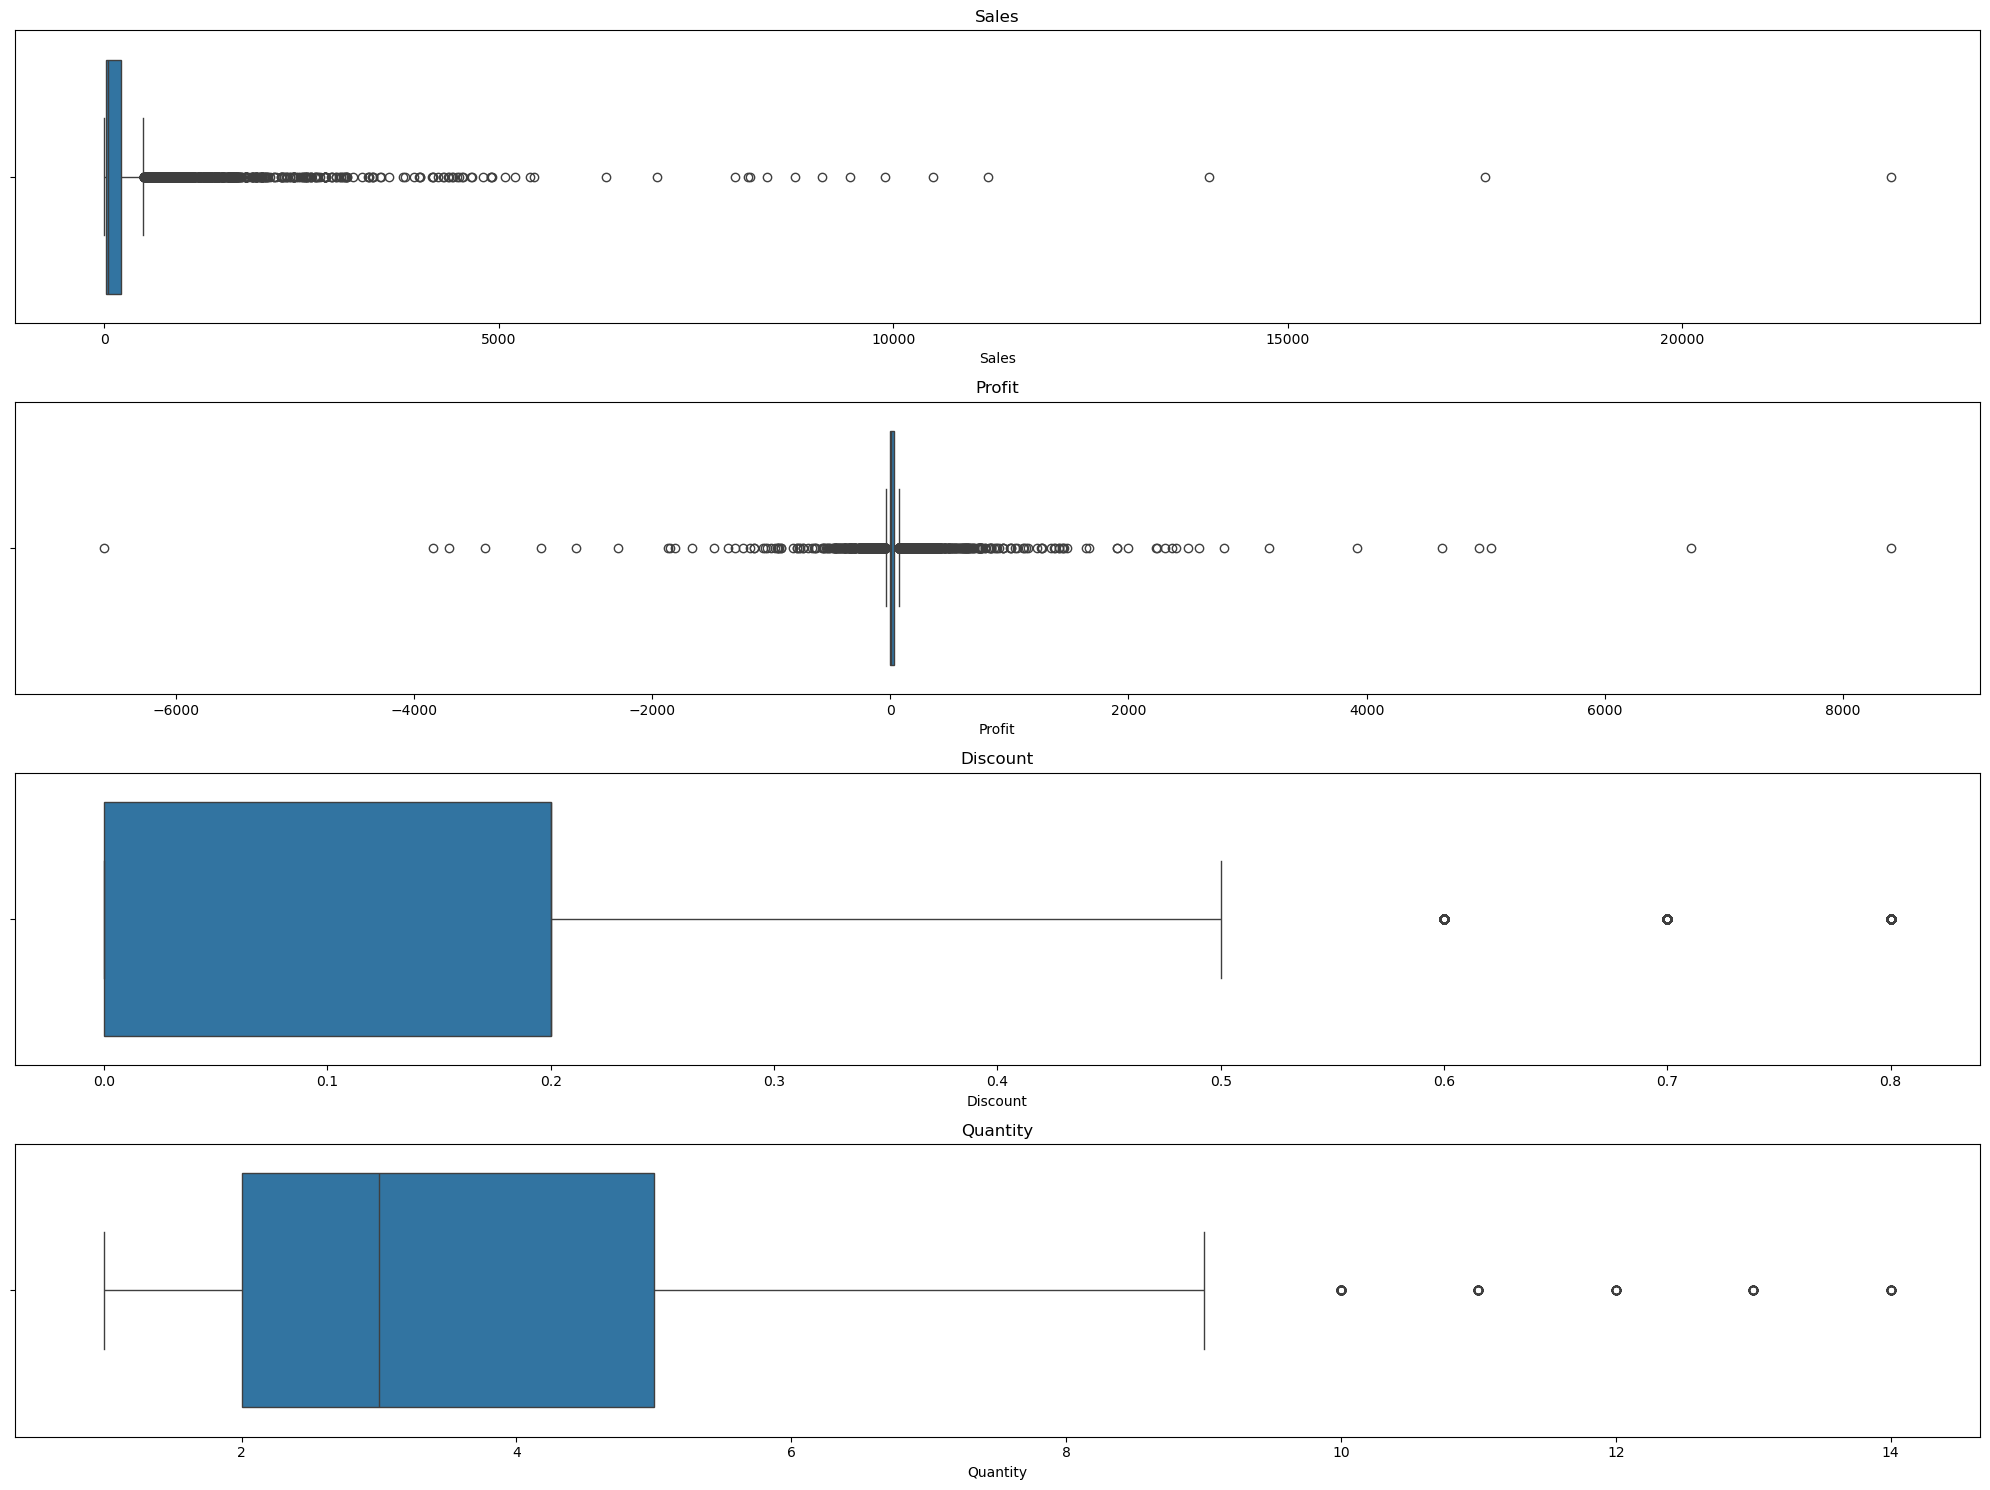

In [12]:
feature = ['Sales', 'Profit', 'Discount', 'Quantity']
plt.figure(figsize=(20, 15))

for idx, col in enumerate(feature, start=1):
    plt.subplot(4, 1, idx)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [13]:
# Observing the data of Sales, Dicsount, Profit, and Quantity
df[['Sales','Discount','Profit','Quantity']].describe()

,Sales,Discount,Profit,Quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,0.156203,28.656896,3.789574
std,623.245101,0.206452,234.260108,2.225110
min,0.444000,0.000000,-6599.978000,1.000000
25%,17.280000,0.000000,1.728750,2.000000
50%,54.490000,0.200000,8.666500,3.000000
75%,209.940000,0.200000,29.364000,5.000000
max,22638.480000,0.800000,8399.976000,14.000000


In [14]:
# Dictionary to store outliers' information
outliers_info = {}

for column in ['Sales', 'Quantity', 'Discount', 'Profit']:
    # Calculate Q1, Q3, and IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers_condition = (df[column] < lower_bound) | (df[column] > upper_bound)
    outliers = df[outliers_condition]

    # Store information in the dictionary
    outliers_info[column] = {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'number_of_outliers': outliers_condition.sum(),  # Count of outliers
        'outliers_indices': outliers.index.tolist()  # Indices of outliers
    }


# summary for outliers_summary

outliers_summary = {key: {'bounds': (value['lower_bound'], value['upper_bound']), 
                          'number_of_outliers': value['number_of_outliers']} 
                    for key, value in outliers_info.items()}

# Creating DataFrame from 'outliers_summary'
outliers_summary_df = pd.DataFrame.from_dict(outliers_summary, orient='index')

# Splitting 'bounds' into 'lower_bound' and 'upper_bound' columns
outliers_summary_df[['lower_bound', 'upper_bound']] = outliers_summary_df['bounds'].apply(pd.Series)

# Dropping the original 'bounds' column
outliers_summary_df.drop('bounds', axis=1, inplace=True)

# Reordering the columns for a better view
outliers_summary_df = outliers_summary_df[['lower_bound', 'upper_bound', 'number_of_outliers']]

# Display DataFrame as a styled table
styled_table = outliers_summary_df.style.format('{:.0f}')
styled_table


,lower_bound,upper_bound,number_of_outliers
Sales,-272,499,1167
Quantity,-2,10,170
Discount,-0,0,856
Profit,-40,71,1881


**Ringkasan**

**1. Sales:**

- Ada 1.167 data penjualan yang nilainya jauh di luar rentang normal. Ini berarti sering terjadi penjualan dengan nilai sangat tinggi atau sangat rendah dibandingkan kebanyakan transaksi lainnya.

**2. Quantity:**

- Terdapat 170 data jumlah barang yang tidak biasa, baik terlalu banyak atau terlalu sedikit dibandingkan pesanan pada umumnya.

**3. Discount:**

- Ada 856 data diskon yang dianggap tidak biasa. Nilai diskon di luar rentang normal, meskipun sebagian besar diskon biasanya bernilai antara 0 hingga 0.5.

**4. Profit:**

- Ditemukan 1.881 data profit yang sangat berbeda dari kebanyakan, baik profit yang sangat besar maupun sangat kecil. Ini menunjukkan banyak transaksi dengan keuntungan yang tidak biasa.


**Kesimpulan**

**1. Sales:** Terdapat banyak angka penjualan yang jauh lebih tinggi atau lebih rendah dari biasanya. Ini berarti mungkin ada banyak penjualan yang sangat tinggi atau sangat rendah dan tampaknya terdapat outlier pada rentang penjualan $10.000 ke atas.

**2. Quantity:** Ada beberapa kasus di mana jumlah barang yang dipesan jauh lebih tinggi atau lebih rendah dari normal. Untuk quantity, jumlah outlier lebih sedikit namun hal ini umum terjadi.

**3. Discount:** Semua nilai diskon dianggap tidak biasa karena semuanya 0. Ini berarti kemungkinan tidak ada diskon yang diberikan.

**4. Profit:** Terdapat banyak profit yang jauh lebih tinggi atau lebih rendah dari biasanya. Ini berarti mungkin ada banyak profit yang sangat tinggi atau sangat rendah dan kondisi fluktuatif ini umum terjadi pada boxplot Profit.

**Dari outlier ini akan saya biarkan begitu saja, karena saya ingin menganalisis tentang profit negatif dalam dataset ini dan alasan mengapa penjualan dengan nilai tinggi bisa menghasilkan profit negatif. Jika saya menghapus atau membuang outlier yang berada pada penjualan $10.000 ke atas, saya tidak dapat menganalisis kondisi ini dan menjawab pernyataan masalah saya.**


## **Memeriksa Anomali pada Sales, Quantity, Discount**

**1. Sales**

In [15]:
print(f"Lowest Sales = {df['Sales'].min()}")

Lowest Sales = 0.444


In [16]:
min_sales = df['Sales'].min()

# Create a DataFrame to display the minimum sales value formatted as currency
sales_info = pd.DataFrame({'Lowest Sales': [min_sales]})
sales_info['Lowest Sales'] = sales_info['Lowest Sales'].apply(lambda x: f'${x:,.2f}')

display(sales_info)

,Lowest Sales
0,$0.44


In [17]:
max_sales = df['Sales'].max()

# Create a DataFrame to display the maximum sales value formatted as currency
sales_info = pd.DataFrame({'Highest Sales': [max_sales]})
sales_info['Highest Sales'] = sales_info['Highest Sales'].apply(lambda x: f'${x:,.2f}')

display(sales_info)

,Highest Sales
0,"$22,638.48"


**Nilai Sales terkecil tidak ada yang bernilai negatif, begitu juga pada nilai Sales terbesar juga tidak ada nilai negatif. Dapat disimpulkan bahwa tidak terdapat anomali pada kolom ini.**

In [18]:
# Sorting the DataFrame 'df descending order based on smallest 'Sales'

# Grouping by 'Sales' and aggregating 'Profit' and 'Quantity' columns
grouped_by_sales_Smallest = df.groupby('Sales').agg({'Profit': 'sum', 'Quantity': 'sum'}).sort_values(by='Sales', ascending=True).reset_index()

total_profit = grouped_by_sales_Smallest['Profit'].sum()

# Formatting 'Sales' as dollar values
grouped_by_sales_Smallest['Sales'] = grouped_by_sales_Smallest['Sales'].apply(lambda x: f'${x:,.2f}')
grouped_by_sales_Smallest['Profit'] = ((grouped_by_sales_Smallest['Profit'] / total_profit) * 100).round(2).astype(str)+'%'
grouped_by_sales_Smallest['Quantity'] = grouped_by_sales_Smallest['Quantity'].apply(lambda x: f'{x} pcs')

grouped_by_sales_Smallest.head()


,Sales,Profit,Quantity
0,$0.44,-0.0%,1 pcs
1,$0.56,-0.0%,1 pcs
2,$0.84,-0.0%,1 pcs
3,$0.85,-0.0%,1 pcs
4,$0.88,-0.0%,1 pcs


Untuk melihat perbedaan antara 3 kolom yaitu Sales, Profit, dan Quantity, sudah benar bahwa pada bagian Sales dengan nilai rendah menghasilkan profit 0 karena jumlah penjualannya juga rendah, sehingga dapat disimpulkan tidak terdapat anomali. **Penjelasan lebih lanjut akan dijelaskan pada bagian Data Analysis.**

In [19]:
# Sorting the DataFrame 'dfn descending order based on Highest 'Sales'

# Grouping by 'Sales' and aggregating 'Profit' and 'Quantity' columns
grouped_by_sales_Largest = df.groupby('Sales').agg({'Profit': 'sum', 'Quantity': 'sum'}).sort_values(by='Sales', ascending=False).reset_index()

total_profit = grouped_by_sales_Largest['Profit'].sum()

# Formatting 'Sales' as dollar values
grouped_by_sales_Largest['Sales'] = grouped_by_sales_Largest['Sales'].apply(lambda x: f'${x:,.2f}')
grouped_by_sales_Largest['Profit'] = ((grouped_by_sales_Largest['Profit'] / total_profit) * 100).round(2).astype(str)+'%'
grouped_by_sales_Largest['Quantity'] = grouped_by_sales_Largest['Quantity'].apply(lambda x: f'{x} pcs')

grouped_by_sales_Largest.head()



,Sales,Profit,Quantity
0,"$22,638.48",-0.63%,6 pcs
1,"$17,499.95",2.93%,5 pcs
2,"$13,999.96",2.35%,4 pcs
3,"$11,199.97",1.37%,4 pcs
4,"$10,499.97",1.76%,3 pcs


Untuk melihat perbedaan antara 3 kolom yaitu Sales, Profit, dan Quantity, tampaknya terdapat anomali karena sebagian besar penjualan justru menghasilkan profit negatif. Hal ini mungkin disebabkan oleh beberapa faktor seperti tingginya biaya produksi atau faktor lainnya. **Penjelasan lebih lanjut akan dijelaskan pada bagian Data Analysis.**


**2. Discount**

In [20]:
min_discount = df['Discount'].min()

# Create a DataFrame to display the minimum discount value formatted as a percentage
discount_info = pd.DataFrame({'Lowest discount': [min_discount * 100]})
discount_info['Lowest discount'] = discount_info['Lowest discount'].round(2).astype(str) + '%'

display(discount_info)

,Lowest discount
0,0.0%


In [21]:
max_discount = df['Discount'].max() * 100  # Converting the maximum discount to a percentage
discount_info = pd.DataFrame({'Highest discount': [max_discount]})
discount_info['Highest discount'] = discount_info['Highest discount'].round(2).astype(str) + '%'

display(discount_info)


,Highest discount
0,80.0%


**Sudah benar bahwa pada nilai Discount terkecil tidak terdapat nilai negatif, begitu juga pada nilai Discount terbesar juga tidak ada nilai negatif. Dapat disimpulkan bahwa tidak terdapat anomali pada kolom ini.**


In [22]:
# Grouping by 'Discount' and aggregating 'Profit', 'Quantity', and 'Sales' columns
grouped_by_discount_Largest = df.groupby('Discount').agg({'Profit': 'sum', 'Quantity': 'sum', 'Sales': 'sum'}).sort_values(by='Discount', ascending=False).reset_index()

total_profit = grouped_by_discount_Largest['Profit'].sum()

# Formatting 'Sales' as dollar values
grouped_by_discount_Largest['Sales'] = grouped_by_discount_Largest['Sales'].apply(lambda x: f'${x:,.3f}')
grouped_by_discount_Largest['Profit'] = ((grouped_by_discount_Largest['Profit'] / total_profit) * 100).round(2).astype(str)+'%'
grouped_by_discount_Largest['Quantity'] = grouped_by_discount_Largest['Quantity'].apply(lambda x: f'{x} pcs')
grouped_by_discount_Largest['Discount'] = (grouped_by_discount_Largest['Discount'] * 100).round(2).astype(str)+'%'

grouped_by_discount_Largest.head()


,Discount,Profit,Quantity,Sales
0,80.0%,-10.66%,1188 pcs,"$16,963.756"
1,70.0%,-13.99%,1660 pcs,"$40,620.282"
2,60.0%,-2.08%,501 pcs,"$6,644.700"
3,50.0%,-7.16%,241 pcs,"$58,918.540"
4,45.0%,-0.87%,45 pcs,"$5,484.974"


Untuk melihat perbedaan antara keempat kolom yaitu Discount, Sales, Profit, dan Quantity, sudah benar bahwa pada bagian Discount tidak terdapat anomali karena profit negatif. **Penjelasan lebih lanjut akan dijelaskan pada bagian Data Analysis.**

In [23]:
# Grouping by 'Discount' and aggregating 'Profit', 'Quantity', and 'Sales' columns
grouped_by_discount_Smallest = df.groupby('Discount').agg({'Profit': 'sum', 'Quantity': 'sum', 'Sales': 'sum'}).sort_values(by='Discount', ascending=True).reset_index()

total_profit = grouped_by_discount_Smallest['Profit'].sum()

# Formatting 'Sales' as dollar values
grouped_by_discount_Smallest['Sales'] = grouped_by_discount_Smallest['Sales'].apply(lambda x: f'${x:,.3f}')
grouped_by_discount_Smallest['Profit'] = ((grouped_by_discount_Smallest['Profit'] / total_profit) * 100).round(2).astype(str)+'%'
grouped_by_discount_Smallest['Quantity'] = grouped_by_discount_Smallest['Quantity'].apply(lambda x: f'{x} pcs')
grouped_by_discount_Smallest['Discount'] = (grouped_by_discount_Smallest['Discount'] * 100).round(2).astype(str)+'%'

grouped_by_discount_Smallest.head()

,Discount,Profit,Quantity,Sales
0,0.0%,112.08%,18267 pcs,"$1,087,908.470"
1,10.0%,3.15%,373 pcs,"$54,369.351"
2,15.0%,0.5%,198 pcs,"$27,558.521"
3,20.0%,31.54%,13660 pcs,"$764,594.368"
4,30.0%,-3.62%,849 pcs,"$103,226.655"


Untuk melihat perbedaan antara keempat kolom yaitu Discount, Sales, Profit, dan Quantity, sudah benar bahwa pada bagian Discount tidak terdapat anomali karena pada diskon 0% justru memberikan keuntungan (profit) tertinggi bagi perusahaan serta jumlah penjualan (quantity) terbanyak. **Penjelasan lebih lanjut akan dijelaskan pada bagian Data Analysis.**


**3. Profit**

In [24]:
# Grouping by 'Discount' and aggregating 'Profit', 'Quantity', and 'Sales' columns
grouped_by_profit_Smallest = df.groupby('Profit').agg({'Discount': 'sum', 'Quantity': 'sum', 'Sales': 'sum'}).sort_values(by='Profit', ascending=True).reset_index()

total_profit = grouped_by_profit_Smallest['Profit'].sum()

# Formatting 'Sales' as dollar values
grouped_by_profit_Smallest['Sales'] = grouped_by_profit_Smallest['Sales'].apply(lambda x: f'${x:,.3f}')
grouped_by_profit_Smallest['Profit'] = ((grouped_by_profit_Smallest['Profit'] / total_profit) * 100).round(2).astype(str)+'%'
grouped_by_profit_Smallest['Quantity'] = grouped_by_profit_Smallest['Quantity'].apply(lambda x: f'{x} pcs')
grouped_by_profit_Smallest['Discount'] = (grouped_by_profit_Smallest['Discount'] * 100).round(2).astype(str)+'%'

grouped_by_profit_Smallest.head()

,Profit,Discount,Quantity,Sales
0,-2.97%,70.0%,5 pcs,"$4,499.985"
1,-1.73%,50.0%,4 pcs,"$7,999.980"
2,-1.67%,80.0%,8 pcs,"$2,177.584"
3,-1.53%,70.0%,5 pcs,"$2,549.985"
4,-1.32%,80.0%,5 pcs,"$1,889.990"


Untuk melihat perbedaan antara keempat kolom yaitu Profit, Sales, Discount, dan Quantity, sudah benar bahwa pada bagian profit terdapat nilai negatif yang berarti perusahaan mengalami kesulitan dalam mendapatkan keuntungan dari penjualan, jumlah barang yang terjual, dan pengaruh diskon sehingga tidak terdapat anomali. **Penjelasan lebih lanjut akan dijelaskan pada bagian Data Analysis.**

In [25]:
# Grouping by 'Discount' and aggregating 'Profit', 'Quantity', and 'Sales' columns
grouped_by_profit_Largest = df.groupby('Profit').agg({'Discount': 'sum', 'Quantity': 'sum', 'Sales': 'sum'}).sort_values(by='Profit', ascending=False).reset_index()

total_profit = grouped_by_profit_Largest['Profit'].sum()

# Formatting 'Sales' as dollar values
grouped_by_profit_Largest['Sales'] = grouped_by_profit_Largest['Sales'].apply(lambda x: f'${x:,.3f}')
grouped_by_profit_Largest['Profit'] = ((grouped_by_profit_Largest['Profit'] / total_profit) * 100).round(2).astype(str)+'%'
grouped_by_profit_Largest['Quantity'] = grouped_by_profit_Largest['Quantity'].apply(lambda x: f'{x} pcs')
grouped_by_profit_Largest['Discount'] = (grouped_by_profit_Largest['Discount'] * 100).round(2).astype(str)+'%'

grouped_by_profit_Largest.head()


,Profit,Discount,Quantity,Sales
0,3.78%,0.0%,5 pcs,"$17,499.950"
1,3.02%,0.0%,4 pcs,"$13,999.960"
2,2.27%,0.0%,3 pcs,"$10,499.970"
3,2.23%,0.0%,13 pcs,"$9,892.740"
4,2.08%,0.0%,5 pcs,"$9,449.950"


"Untuk melihat perbedaan antara 4 kolom yang terdiri dari **Profit, Sales, Discount, Quantity**, sudah benar bahwa pada bagian profit, saya mengubahnya dari nilai mata uang ($) menjadi persentase untuk melihat persentase profit dari penjualan, kuantitas terjual, dan efek diskon, sehingga tidak ada anomali. **Penjelasan lebih lanjut akan dijelaskan di Bagian Analisis Data**."

**4. Quantity**


In [26]:
# Calculate the minimum quantity
max_quantity = df['Quantity'].min() 

# Prepare the DataFrame
quantity_info = pd.DataFrame({'Minimum quantity': [max_quantity]})
quantity_info['Minimum quantity'] = quantity_info['Minimum quantity'].astype(int).astype(str) + ' pcs'

display(quantity_info)

,Minimum quantity
0,1 pcs


In [27]:
# Calculate the maximum quantity
max_quantity = df['Quantity'].max() 

# Prepare the DataFrame
quantity_info = pd.DataFrame({'Highest quantity': [max_quantity]})
quantity_info['Highest quantity'] = quantity_info['Highest quantity'].astype(int).astype(str) + ' pcs'

display(quantity_info)



,Highest quantity
0,14 pcs


**kuantitas terkecil tidak ada nilai negatif dan pada kuantitas tertinggi juga tidak ada nilai negatif. Dapat disimpulkan bahwa tidak ada anomali pada kolom-kolom ini.**


In [28]:

# Grouping by Quantity and getting unique Discount values
grouped_by_quantity = df.groupby('Quantity')['Discount'].apply(lambda x: list(x)).reset_index()

# Merging with the existing grouped data
grouped_by_quantity_Largest = grouped_by_quantity.merge(
    df.groupby('Quantity').agg({'Profit': 'sum', 'Sales': 'sum'}).reset_index(),
    on='Quantity'
)

# Calculating the total profit
total_profit = grouped_by_quantity_Largest['Profit'].sum()

# Formatting 'Sales' as dollar values and calculating percentage for 'Profit'
grouped_by_quantity_Largest['Sales'] = grouped_by_quantity_Largest['Sales'].apply(lambda x: f'${x:,.3f}')
grouped_by_quantity_Largest['Profit'] = ((grouped_by_quantity_Largest['Profit'] / total_profit) * 100).round(2).astype(str) + '%'

# Formatting Discount as a list of percentages
grouped_by_quantity_Largest['Discount Rates'] = grouped_by_quantity_Largest['Discount'].apply(lambda x: [f"{rate * 100}%" for rate in x])


Comparison_by_Quantity = pd.DataFrame({
    'Quantity': grouped_by_quantity_Largest['Quantity'],
    'Discount Rates': grouped_by_quantity_Largest['Discount Rates'],
    'Sales': grouped_by_quantity_Largest['Sales'],
    'Profit Percentage': grouped_by_quantity_Largest['Profit']
})

Comparison_by_Quantity


,Quantity,Discount Rates,Sales,Profit Percentage
0,1,"[0.0%, 0.0%, 20.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 70.0%, 20.0%, 20.0%, 70.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 0.0%, 20.0%, 10.0%, 0.0%, 0.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 20.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 20.0%, 20.0%, 20.0%, 0.0%, 60.0%, 0.0%, 20.0%, 0.0%, 0.0%, 50.0%, 0.0%, 0.0%, 0.0%, 20.0%, 20.0%, 0.0%, 20.0%, 0.0%, 20.0%, 20.0%, 20.0%, 0.0%, 0.0%, 0.0%, 50.0%, 0.0%, 0.0%, 20.0%, 0.0%, 50.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 20.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 20.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, ...]","$53,251.935",2.6%
1,2,"[0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 30.0%, 20.0%, 70.0%, 20.0%, 20.0%, 0.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 70.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 0.0%, 80.0%, 20.0%, 0.0%, 0.0%, 20.0%, 70.0%, 50.0%, 80.0%, 0.0%, 20.0%, 20.0%, 20.0%, 20.0%, 20.0%, 20.0%, 45.0%, 70.0%, 0.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 80.0%, 0.0%, 0.0%, 20.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 0.0%, 0.0%, 20.0%, 40.0%, 70.0%, 20.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 20.0%, 20.0%, 20.0%, 0.0%, 70.0%, 20.0%, 70.0%, 40.0%, ...]","$289,091.480",13.42%
2,3,"[0.0%, 20.0%, 20.0%, 20.0%, 80.0%, 20.0%, 0.0%, 0.0%, 20.0%, 20.0%, 32.0%, 30.0%, 0.0%, 0.0%, 0.0%, 80.0%, 60.0%, 20.0%, 0.0%, 20.0%, 0.0%, 0.0%, 20.0%, 20.0%, 80.0%, 20.0%, 70.0%, 20.0%, 0.0%, 0.0%, 30.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 40.0%, 20.0%, 45.0%, 20.0%, 20.0%, 60.0%, 60.0%, 0.0%, 0.0%, 40.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 50.0%, 20.0%, 20.0%, 20.0%, 0.0%, 50.0%, 0.0%, 0.0%, 20.0%, 0.0%, 20.0%, 40.0%, 70.0%, 20.0%, 20.0%, 0.0%, 10.0%, 20.0%, 80.0%, 20.0%, 20.0%, 45.0%, 20.0%, 0.0%, 80.0%, 20.0%, 20.0%, 0.0%, 20.0%, 0.0%, 30.0%, 10.0%, 0.0%, 0.0%, ...]","$422,060.601",19.91%
3,4,"[0.0%, 20.0%, 20.0%, 20.0%, 20.0%, 0.0%, 20.0%, 0.0%, 20.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 20.0%, 80.0%, 0.0%, 20.0%, 20.0%, 0.0%, 0.0%, 70.0%, 20.0%, 70.0%, 0.0%, 0.0%, 20.0%, 0.0%, 20.0%, 0.0%, 20.0%, 20.0%, 0.0%, 30.0%, 20.0%, 0.0%, 20.0%, 20.0%, 0.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 80.0%, 70.0%, 20.0%, 0.0%, 32.0%, 20.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 20.0%, 0.0%, 60.0%, 20.0%, 20.0%, 0.0%, 0.0%, 0.0%, 20.0%, 20.0%, 40.0%, 70.0%, 20.0%, 0.0%, 20.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 50.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 20.0%, 0.0%, 0.0%, 45.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 20.0%, ...]","$323,670.994",15.44%
4,5,"[45.0%, 0.0%, 80.0%, 60.0%, 0.0%, 0.0%, 10.0%, 30.0%, 60.0%, 0.0%, 20.0%, 40.0%, 0.0%, 20.0%, 0.0%, 80.0%, 20.0%, 0.0%, 0.0%, 50.0%, 0.0%, 20.0%, 60.0%, 50.0%, 0.0%, 20.0%, 20.0%, 80.0%, 20.0%, 20.0%, 20.0%, 20.0%, 70.0%, 0.0%, 0.0%, 20.0%, 20.0%, 70.0%, 0.0%, 0.0%, 20.0%, 20.0%, 0.0%, 20.0%, 20.0%, 70.0%, 0.0%, 0.0%, 0.0%, 15.0%, 20.0%, 0.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 20.0%, 20.0%, 80.0%, 10.0%, 20.0%, 20.0%, 0.0%, 20.0%, 30.0%, 0.0%, 20.0%, 20.0%, 0.0%, 0.0%, 20.0%, 20.0%, 20.0%, 20.0%, 20.0%, 20.0%, 0.0%, 70.0%, 20.0%, 20.0%, 0.0%, 30.0%, 70.0%, 20.0%, 10.0%, 0.0%, 0.0%, 20.0%, 0.0%, 20.0%, 0.0%, 20.0%, 0.0%, 20.0%, 0.0%, 20.0%, ...]","$415,661.697",17.29%
5,6,"[20.0%, 0.0%, 20.0%, 70.0%, 0.0%, 0.0%, 0.0%, 20.0%, 0.0%, 20.0%, 0.0%, 20.0%, 0.0%, 50.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 20.0%, 0.0%, 20.0%, 20.0%, 0.0%, 0.0%, 20.0%, 70.0%, 20.0%, 20.0%, 20.0%, 20.0%, 0.0%, 50.0%, 0.0%, 20.0%, 20.0%, 20.0%, 0.0%, 20.0%, 0.0%, 0.0%, 20.0%, 0.0%, 0.0%, 0.0%, 0.0%, 20.0%, 70.0%, 0.0%, 0.0%, 70.0%, 20.0%, 20.0%, 20.0%, 10.0%, 20.0%, 0.0%, 20.0%, 20.0%, 0.0%, 20.0%, 0.0%, 20.0%, 0.0%, 0.0%, 70.0%, 80.0%, 20.0%, 70.0%, 0.0%, 0.0%, 20.0%, 20.0%, 0.0%

Untuk melihat perbedaan antara 4 kolom yang terdiri dari **Quantity, Sales, Discount, Profit**, sudah benar bahwa pada bagian kuantitas, tidak ada diskon negatif dengan rentang 0-80% pada berbagai nilai penjualan dan keuntungan. **Penjelasan lebih lanjut akan dijelksan di Bagian Analisis Data**.

**Untuk memeriksa apakah ada anomali pada negara, wilayah (region), sub-wilayah (sub-region), dan kota.**

In [29]:
df.groupby('Region')['Country'].unique().reset_index()

,Region,Country
0,AMER,"[United States, Canada, Costa Rica, Brazil, Chile, Colombia, Mexico, Argentina]"
1,APJ,"[Japan, Australia, Philippines, India, Singapore, New Zealand, South Korea, China, Indonesia, Taiwan]"
2,EMEA,"[Ireland, Germany, Sweden, Italy, Turkey, France, Luxembourg, United Kingdom, Spain, South Africa, Portugal, Belgium, Russia, Netherlands, Poland, Czech Republic, Saudi Arabia, Finland, Israel, Norway, Ukraine, United Arab Emirates, Greece, Austria, Egypt, Denmark, Croatia, Qatar, Slovenia, Iceland]"


Dari tabel-tabel di atas, kita dapat melihat bahwa ada 3 wilayah yang terdiri dari AMER, APJ, dan EMEA (Wilayah Amerika, Wilayah Asia-Pasifik dan Jepang, serta Wilayah Eropa, Timur Tengah, dan Afrika). Negara-negara yang tercantum dalam setiap kategori tampaknya cocok dengan wilayah-wilayah ini berdasarkan lokasi benua mereka.

In [30]:
df.groupby('Subregion')['Country'].unique().reset_index()

,Subregion,Country
0,ANZ,"[Australia, New Zealand]"
1,APAC,"[Philippines, Singapore, South Korea, China, Indonesia, Taiwan]"
2,EU,[Italy]
3,EU-EAST,"[Russia, Czech Republic, Israel, Ukraine, Greece]"
4,EU-WEST,"[Germany, France, Luxembourg, Spain, Portugal, Belgium, Netherlands, Poland, Austria, Denmark, Croatia, Slovenia, Iceland]"
5,IND,[India]
6,JAPN,[Japan]
7,LATAM,"[Costa Rica, Brazil, Chile, Colombia, Mexico, Argentina]"
8,MEA,"[Turkey, South Africa, Saudi Arabia, United Arab Emirates, Egypt, Qatar]"
9,NAMER,"[United States, Canada]"


**Pengkategorian ini lebih detail dibandingkan menggunakan wilayah (region), dari tabel ini kita bisa melihat setiap negara berada di subwilayah (subregion) yang tepat.** Ini terlihat detail dan mencakup berbagai lokasi geografis dalam pembagian benua yang lebih luas.

Penggunaan subwilayah cukup berguna dalam menganalisis dan memahami perbedaan regional dalam praktik bisnis, dan untuk strategi pemasaran yang lebih terarah.

In [31]:
df.groupby('Subregion')['City'].count().reset_index()

,Subregion,City
0,ANZ,529
1,APAC,447
2,EU,110
3,EU-EAST,343
4,EU-WEST,1614
5,IND,149
6,JAPN,985
7,LATAM,1158
8,MEA,396
9,NAMER,2507


**Angka-angka ini mewakili jumlah kota di dalam setiap subwilayah.**

In [32]:
df.groupby('Country')['City'].unique().reset_index()

,Country,City
0,Argentina,"[Córdoba, Buenos Aires, Mendoza, Rosario]"
1,Australia,"[Wollongong, Sydney, Canberra, Geelong, Melbourne, Adelaide, Brisbane, Hobart, Gold Coast, Perth]"
2,Austria,[Vienna]
3,Belgium,"[Brussels, Antwerp, Ghent]"
4,Brazil,"[Salvador, Rio de Janeiro, São Paulo, Manaus, Belo Horizonte, Brasília]"
5,Canada,"[Toronto, Vancouver, Hamilton, Ottawa, Montreal, Calgary, Quebec, Regina, Winnipeg, Victoria]"
6,Chile,"[Puente Alto, Santiago, Antofagasta]"
7,China,"[Shanghai, Shenzhen, Guangzhou, Beijing, Tianjin, Suzhou, Chengdu]"
8,Colombia,"[Bogotá, Medellín, Cali]"
9,Costa Rica,[San José]


**Tabel-tabel ini merepresentasikan kota-kota besar di setiap negara. Ini memberikan gambaran umum yang baik mengenai pusat-pusat perkotaan di seluruh dunia dan dari tabel-tabel ini tampaknya pasangan kota dan negara sudah berada dalam pasangan yang benar.**

**Untuk memeriksa dan menemukan salah eja pada kolom Kota karena ada banyak kota dalam dataset ini.**

In [33]:
np.sort(df['City'].unique())

array(['Abu Dhabi', 'Adelaide', 'Aichi', 'Alexandria', 'Alicante',
       'Amsterdam', 'Anaheim', 'Ankara', 'Antofagasta', 'Antwerp',
       'Arlington', 'Athens', 'Atlanta', 'Auckland', 'Aurora', 'Austin',
       'Baltimore', 'Bandung', 'Bangalore', 'Barcelona', 'Bari',
       'Beijing', 'Belfast', 'Belo Horizonte', 'Berlin', 'Birmingham',
       'Bogotá', 'Bologna', 'Brasília', 'Brescia', 'Brighton', 'Brisbane',
       'Bristol', 'Brno', 'Brussels', 'Buenos Aires', 'Buffalo',
       'Burlington', 'Bursa', 'Busan', 'Cabo San Lucas', 'Cairo',
       'Calgary', 'Cali', 'Canberra', 'Cancun', 'Cape Town', 'Cardiff',
       'Catania', 'Charlotte', 'Chengdu', 'Chennai', 'Chiba', 'Chicago',
       'Cleveland', 'Clinton', 'Cologne', 'Columbia', 'Columbus',
       'Copenhagen', 'Cork', 'Córdoba', 'Daegu', 'Dallas', 'Davao City',
       'Delhi', 'Denver', 'Detroit', 'Dhahran', 'Doha', 'Donetsk',
       'Dresden', 'Dubai', 'Dublin', 'Edinburgh', 'Espoo', 'Everett',
       'Florence', 'Fort Worth

**Potensi Kesalahan Eja pada Daftar Kota Ini**

* Puente Alto dan Puerto Vallarta dieja dengan benar.
* Lisboa adalah nama Portugis untuk Lisbon, yang akurat.
* Reykjavík dan 'Yekaterinburg' dieja dengan benar.
* The Hague adalah nama Inggris untuk 'Den Haag', kota di Belanda.

**Kita dapat menyimpulkan bahwa sebagian besar nama tampaknya dieja dengan benar untuk kota atau wilayah masing-masing.**

## **Memeriksa Anomali pada Order ID & Order Date**


In [34]:
df['Order ID'].nunique()

5009

In [35]:
df.groupby('Order ID')['License'].unique().reset_index().head()


,Order ID,License
0,AMER-2020-100090,"[4BEAB9UXKH, AVBMH39MTD]"
1,AMER-2020-100279,[NI5MITNJ98]
2,AMER-2020-100363,"[0O2MCUTMFW, 7ZEJI08M1P]"
3,AMER-2020-100762,"[9WNGMUMGIU, QLK9TG5206, V5SQA48WYZ, 5F2LX40BDP]"
4,AMER-2020-100860,[T3NURF3EZL]


In [36]:
df['License'].duplicated().sum()

0

**1. Pola ID Pesanan:**

* ID Pesanan tampaknya mengikuti pola tertentu: "AMER-2020-" diikuti dengan urutan angka. Hal ini menunjukkan kemungkinan sistem penomoran yang didasarkan pada wilayah masing-masing (AMER untuk wilayah Amerika) dan tahun 2020.

**2. Keberagaman Format License Key:**

* Format dari license key terlihat alfanumerik, kemungkinan dihasilkan secara acak atau berdasarkan algoritma tertentu. Beberapa kunci lebih panjang (10 karakter), sementara yang lain lebih pendek (9 karakter). Jadi, tidak ada masalah dengan format lisensi ini.

**3. Unique Key per Pesanan:**

* Setiap pesanan tampaknya memiliki kumpulan license key yang unik, menunjukkan pembelian atau alokasi individu. Oleh karena itu, tidak boleh ada duplikat dalam setiap lisensi.


## **Memeriksa Anomali pada Industry, Product, & Segment**

In [37]:
df.groupby('Industry')['Product'].unique().reset_index()

,Industry,Product
0,Communications,"[ChatBot Plugin, Marketing Suite - Gold, OneView, Data Smasher, ContactMatcher, Support, Big Ol Database, SaaS Connector Pack, SaaS Connector Pack - Gold, FinanceHub, Site Analytics, Storage, Marketing Suite]"
1,Consumer Products,"[ContactMatcher, Site Analytics, SaaS Connector Pack, Data Smasher, Support, OneView, SaaS Connector Pack - Gold, ChatBot Plugin, FinanceHub, Marketing Suite, Big Ol Database, Marketing Suite - Gold, Storage, Alchemy]"
2,Energy,"[Marketing Suite, FinanceHub, ContactMatcher, Marketing Suite - Gold, Support, Site Analytics, OneView, Storage, SaaS Connector Pack, Big Ol Database, ChatBot Plugin, Data Smasher, Alchemy, SaaS Connector Pack - Gold]"
3,Finance,"[SaaS Connector Pack, ChatBot Plugin, Site Analytics, ContactMatcher, OneView, SaaS Connector Pack - Gold, Marketing Suite, FinanceHub, Marketing Suite - Gold, Data Smasher, Support, Storage, Big Ol Database, Alchemy]"
4,Healthcare,"[OneView, ContactMatcher, FinanceHub, SaaS Connector Pack, Marketing Suite - Gold, SaaS Connector Pack - Gold, Site Analytics, Data Smasher, Support, Storage, Alchemy, ChatBot Plugin, Marketing Suite, Big Ol Database]"
5,Manufacturing,"[Marketing Suite - Gold, ContactMatcher, Data Smasher, FinanceHub, SaaS Connector Pack, Support, OneView, Storage, Marketing Suite, ChatBot Plugin, Site Analytics, Big Ol Database, SaaS Connector Pack - Gold, Alchemy]"
6,Misc,"[Support, OneView, Data Smasher, SaaS Connector Pack, ContactMatcher, SaaS Connector Pack - Gold, ChatBot Plugin, Site Analytics, Marketing Suite - Gold, FinanceHub, Storage, Big Ol Database, Alchemy, Marketing Suite]"
7,Retail,"[Marketing Suite - Gold, ChatBot Plugin, OneView, FinanceHub, Storage, Site Analytics, ContactMatcher, Data Smasher, SaaS Connector Pack, Support, Big Ol Database, SaaS Connector Pack - Gold, Marketing Suite, Alchemy]"
8,Tech,"[ContactMatcher, Marketing Suite, SaaS Connector Pack, SaaS Connector Pack - Gold, ChatBot Plugin, Marketing Suite - Gold, Data Smasher, Support, FinanceHub, Site Analytics, Storage, Big Ol Database, OneView, Alchemy]"
9,Transportation,"[ContactMatcher, SaaS Connector Pack, Marketing Suite - Gold, Data Smasher, FinanceHub, ChatBot Plugin, Site Analytics, Support, Big Ol Database, OneView, Storage, Alchemy, Marketing Suite, SaaS Connector Pack - Gold]"


**Tabel ini merepresentasikan berbagai industri dan produk yang terkait dengan masing-masing industri. Setiap baris menunjukkan satu industri, dan kolom 'Product' berisi daftar produk yang berhubungan dengan industri tersebut.**

In [38]:
df.groupby('Segment')['Product'].unique().reset_index()

,Segment,Product
0,Enterprise,"[OneView, ContactMatcher, Support, SaaS Connector Pack - Gold, Marketing Suite, FinanceHub, Site Analytics, Marketing Suite - Gold, SaaS Connector Pack, Data Smasher, ChatBot Plugin, Storage, Big Ol Database, Alchemy]"
1,SMB,"[Marketing Suite, FinanceHub, ContactMatcher, Marketing Suite - Gold, SaaS Connector Pack, ChatBot Plugin, Site Analytics, OneView, Support, Data Smasher, SaaS Connector Pack - Gold, Storage, Big Ol Database, Alchemy]"
2,Strategic,"[FinanceHub, ChatBot Plugin, OneView, Site Analytics, SaaS Connector Pack, Marketing Suite - Gold, Data Smasher, ContactMatcher, Storage, SaaS Connector Pack - Gold, Support, Marketing Suite, Big Ol Database, Alchemy]"


**Tabel ini merepresentasikan adanya 3 segmen yaitu Enterprise, SMB, dan Strategic yang masing-masing berisi daftar produk yang terkait dengan setiap segmen tersebut.**

In [39]:
df.groupby('Segment')['Industry'].unique().reset_index()

,Segment,Industry
0,Enterprise,"[Healthcare, Misc, Finance, Energy, Retail, Manufacturing, Consumer Products, Transportation, Tech, Communications]"
1,SMB,"[Energy, Finance, Tech, Manufacturing, Retail, Consumer Products, Healthcare, Communications, Transportation, Misc]"
2,Strategic,"[Energy, Retail, Consumer Products, Manufacturing, Tech, Finance, Transportation, Healthcare, Communications, Misc]"


Tabel ini merepresentasikan bahwa segmen (Enterprise, SMB, dan Strategic) terkait dengan berbagai industri, dan dari tabel ini tampaknya terdapat kesamaan antara ketiga segmen tersebut sehingga tidak ada anomali pada kolom ini. **Penjelasan lebih lanjut akan dijelaskan pada bagian Analisis Data.**


## **Uji Normalitas / Distribusi**

* Uji normalitas dalam data sangat penting karena banyak metode statistik yang mengasumsikan bahwa data mengikuti distribusi normal.
* Ketika data terdistribusi normal, data akan berperilaku dengan cara yang dapat diprediksi di sekitar nilai rata-rata.
* Jika data tidak mengikuti pola ini, hal tersebut dapat memengaruhi akurasi uji statistik dan menghasilkan kesimpulan yang keliru.

**Uji normalitas membantu menentukan apakah data memenuhi asumsi normalitas yang dibutuhkan oleh teknik statistik tertentu. Jika tidak, mungkin diperlukan metode alternatif atau transformasi agar analisis tetap dapat diandalkan.**


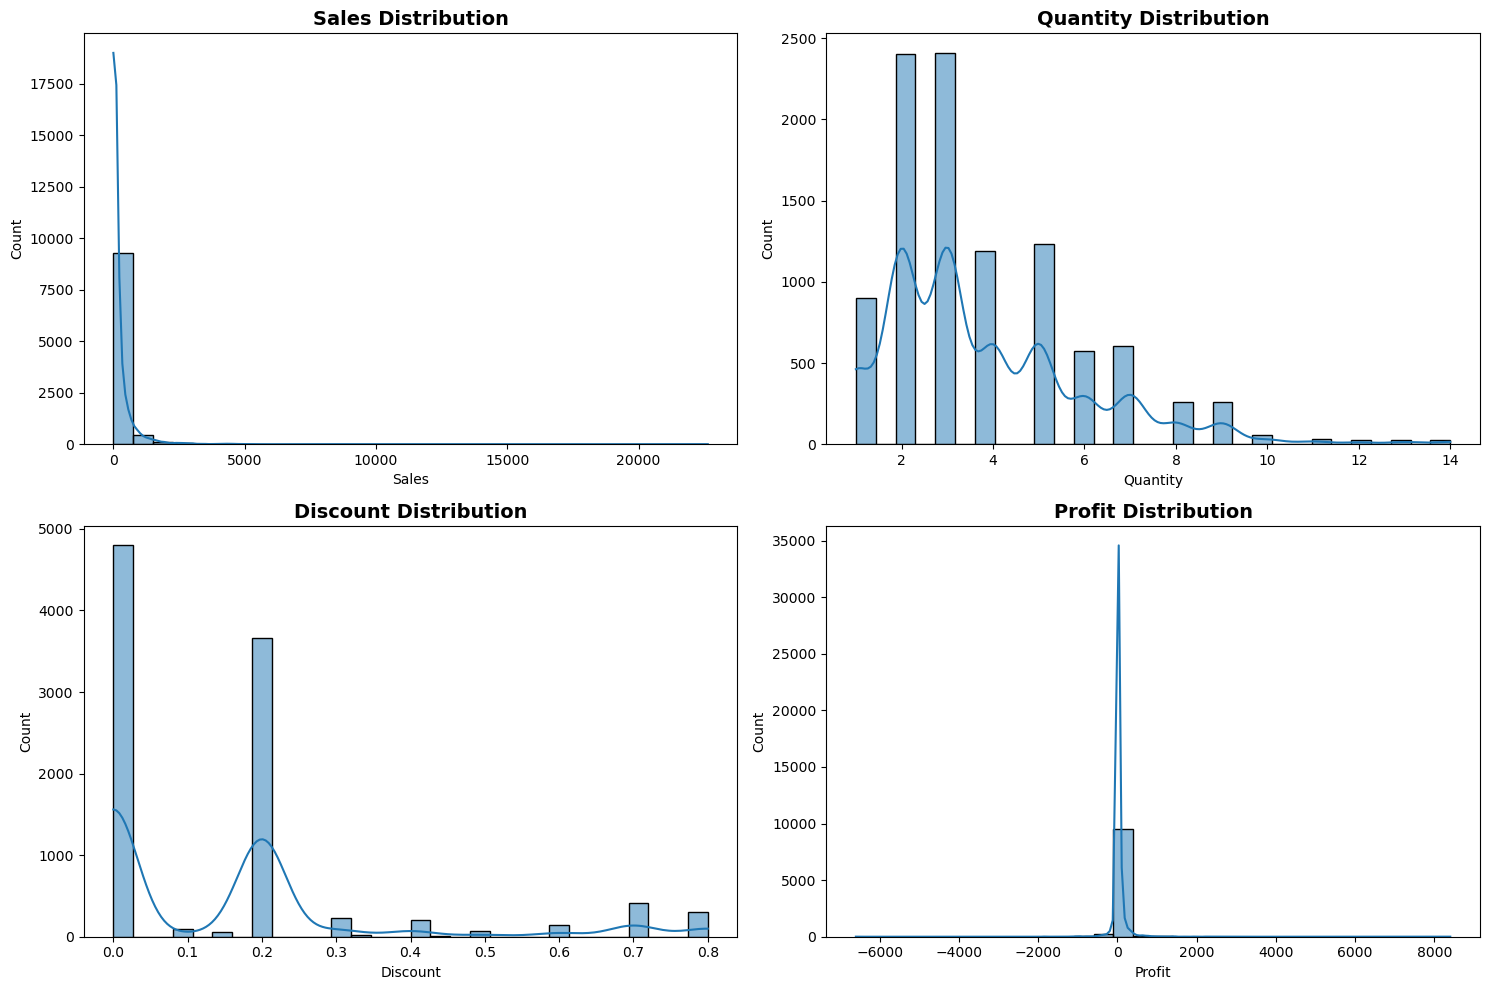

In [40]:
# Analyzing distribution of numerical data consist of Sales, Discount, Quantity, and Profit

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Sales Distribution
sns.histplot(df['Sales'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Sales Distribution', fontdict={'fontsize': 14, 'fontweight': 'bold'})

# Quantity Distribution
sns.histplot(df['Quantity'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Quantity Distribution', fontdict={'fontsize': 14, 'fontweight': 'bold'})

# Discount Distribution
sns.histplot(df['Discount'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Discount Distribution', fontdict={'fontsize': 14, 'fontweight': 'bold'})

# Profit Distribution
sns.histplot(df['Profit'], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Profit Distribution', fontdict={'fontsize': 14, 'fontweight': 'bold'})

plt.tight_layout()
plt.show()

**Ringkasan Normalitas dan Distribusi Data:**

1. **Sales (Penjualan):**

   * Sebagian besar transaksi memiliki nilai penjualan yang relatif rendah, sementara beberapa transaksi menunjukkan nilai penjualan yang sangat tinggi. Distribusi ini sangat condong ke kanan, sehingga **data Sales tidak berdistribusi normal**.

2. **Quantity (Kuantitas):**

   * Mayoritas transaksi melibatkan jumlah pembelian yang kecil, dengan sedikit transaksi yang memiliki jumlah sangat besar. Distribusi ini juga condong ke kanan, sehingga **data Quantity tidak berdistribusi normal**.

3. **Discount (Diskon):**

   * Sebagian besar transaksi tidak memiliki diskon yang diterapkan, terlihat dari distribusi tertinggi pada nilai diskon 0%, dan sisanya umumnya rendah dalam menerapkan diskon pada produknya. **Data Discount tidak berdistribusi normal**.

4. **Profit (Keuntungan):**

   * Distribusi profit relatif lebih simetris dibanding kolom lainnya, namun masih terdapat beberapa nilai ekstrem di kedua sisi. **Data Profit tidak berdistribusi normal**.


# **Data Analysis and Visualization**

Analisis akan dilakukan untuk mengidentifikasi faktor-faktor yang memengaruhi **profitabilitas negatif** dalam penjualan produk SaaS di AWS. Analisis ini juga akan memberikan rekomendasi untuk meningkatkan profitabilitas produk tersebut, berdasarkan:

* **Kinerja penjualan perusahaan (Sales Performance)**
* **Analisis pasar (Market Analysis)**

Hasil dari analisis ini diharapkan dapat menjadi dasar pengambilan keputusan yang lebih tepat dalam strategi penjualan dan pemasaran perusahaan.


## **Kategori Produk Spesifik apa yang Berkontribusi terhadap Profit Negatif**


In [41]:
# Grouping by 'Product' and calculating the percentage of profit for each product
profit_percent = df.groupby("Product")[["Profit"]].sum()
total_profit = profit_percent["Profit"].sum()
profit_percent["Profit_Percentage"] = (profit_percent["Profit"] / total_profit) * 100

# Rounding to 2 decimal places and adding '%' symbol for Profit_Percentage
profit_percent["Profit_Percentage"] = profit_percent["Profit_Percentage"].round(2).astype(str) + '%'

# Formatting Profit column to include '$'
profit_percent["Profit"] = profit_percent["Profit"].map('${:,.2f}'.format)

# Sorting by Profit Percentage in descending order
profit_percent = profit_percent.sort_values("Profit_Percentage", ascending=False)

profit_percent

,Profit,Profit_Percentage
Product,,
Marketing Suite - Gold,"$21,278.83",7.43%
OneView,"$18,138.01",6.33%
SaaS Connector Pack,"$13,059.14",4.56%
ContactMatcher,"$12,496.28",4.36%
SaaS Connector Pack - Gold,"$6,964.18",2.43%
ChatBot Plugin,"$6,527.79",2.28%
Alchemy,"$55,617.82",19.42%
Site Analytics,"$44,515.73",15.54%
Data Smasher,"$41,936.64",14.64%


/var/folders/0y/z_p0r0jx1hngmdptdz1f1l5r0000gn/T/ipykernel_33156/28712411.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0)` for the same effect.

  ax = sns.barplot(
/var/folders/0y/z_p0r0jx1hngmdptdz1f1l5r0000gn/T/ipykernel_33156/28712411.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


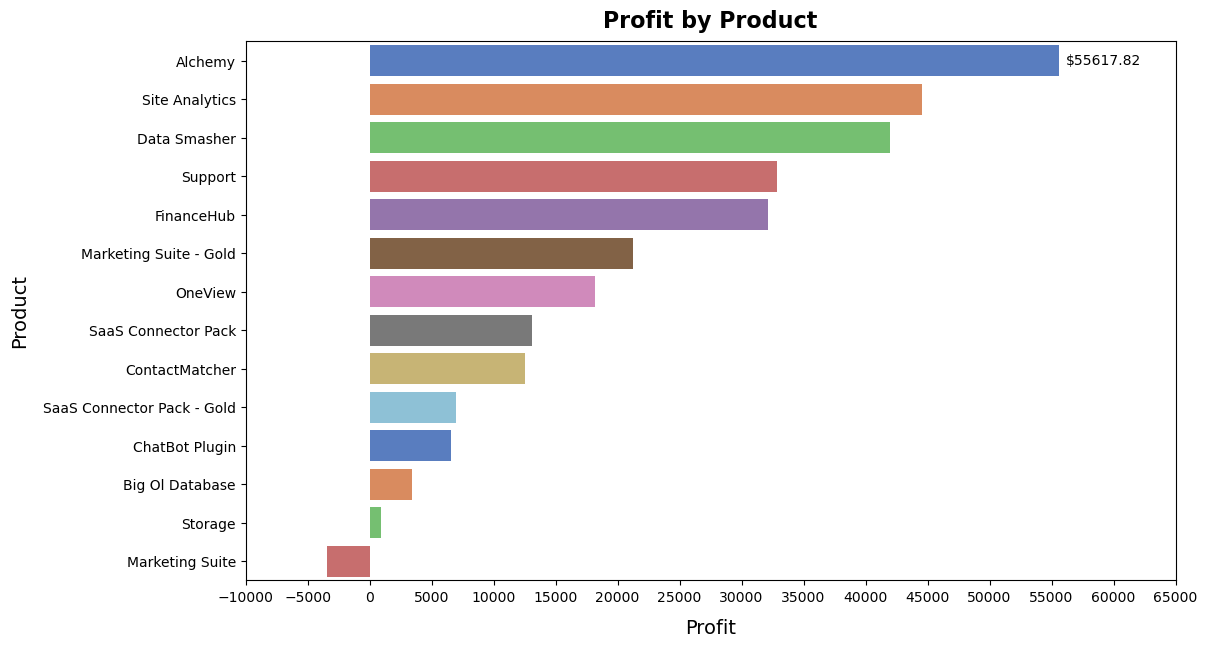

In [42]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df,
    y="Product",
    x="Profit",
    ci=0,
    palette="muted",  
    estimator="sum",
    order=df.groupby("Product")[["Profit"]].sum().sort_values("Profit", ascending=False).index)
container = ax.containers[0]
profit_values = [f'${x:.2f}' for x in container.datavalues]
ax.bar_label(container, labels=profit_values, padding=5)
plt.title("Profit by Product", size=16, pad=10, fontweight='bold')
plt.xlabel("Profit", size=14, labelpad=10)
plt.ylabel("Product", size=14, labelpad=10)
plt.xticks(range(-10000, 65001, 5000))
plt.show()

/var/folders/0y/z_p0r0jx1hngmdptdz1f1l5r0000gn/T/ipykernel_33156/2497243249.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


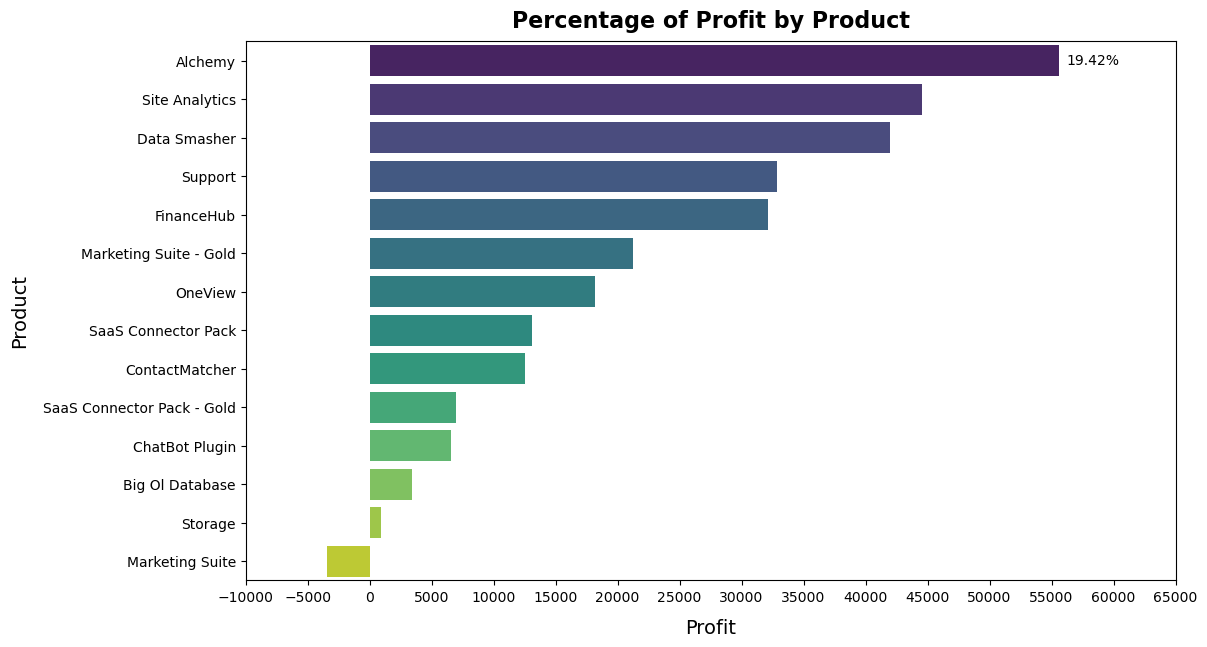

In [43]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df,
    y="Product",
    x="Profit",
    errorbar=('ci', 0),
    palette="viridis",
    estimator="sum",
    order=df.groupby("Product")[["Profit"]].sum().sort_values("Profit", ascending=False).index)
container = ax.containers[0]

# Calculate profit percentages and format as string with '%' symbol
profit_percentages = [(x / df['Profit'].sum() * 100).round(2) for x in container.datavalues]
profit_percentages_str = [f'{x}%' for x in profit_percentages]

ax.bar_label(container, labels=profit_percentages_str, padding=5)
plt.title("Percentage of Profit by Product", size=16, pad=10, fontweight='bold')
plt.xlabel("Profit", size=14, labelpad=10)
plt.ylabel("Product", size=14, labelpad=10)
plt.xticks(range(-10000, 65001, 5000))
plt.show()

**Insight**

**1. Produk dengan Profit Positif:**

* Produk dengan kinerja terbaik dalam hal profit mencakup **Alchemy, Site Analytics, Data Smasher, Support, FinanceHub, Marketing Suite - Gold**, dan **OneView**.

  * Produk-produk ini secara kolektif memberikan kontribusi signifikan terhadap total profit perusahaan, dengan **Alchemy, Site Analytics**, dan **Data Smasher** sebagai penyumbang terbesar.

**2. Produk dengan Profit Negatif:**

* **Marketing Suite** menunjukkan persentase profit yang negatif, yang berarti produk ini beroperasi dengan kerugian.

  * Produk ini memberikan dampak negatif terhadap profitabilitas keseluruhan lini produk perusahaan.

**Insight Utama:**

Produk seperti **Alchemy, Site Analytics**, dan **Data Smasher** adalah produk paling menguntungkan bagi perusahaan AWS SaaS karena mampu menghasilkan profit yang besar. Sementara itu, **produk Marketing Suite berkinerja buruk dan mengalami kerugian**, yang kemungkinan memerlukan investigasi lebih lanjut terhadap **struktur biaya atau permintaannya di pasar**.


### **Profit Distribution**


/var/folders/0y/z_p0r0jx1hngmdptdz1f1l5r0000gn/T/ipykernel_33156/2457958252.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([profitable_products['Profit'], non_profitable_products['Profit']], labels=['Profitable', 'Non-Profitable'])


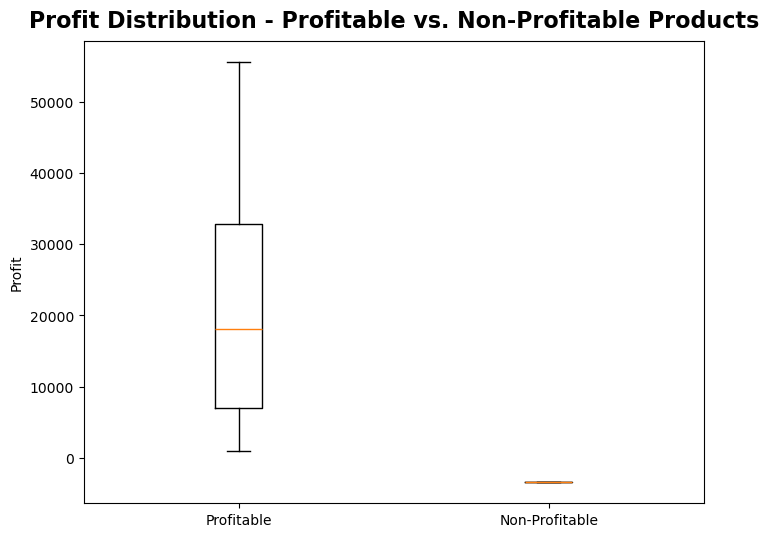

In [44]:
# Group data by 'Product' and calculate total profit for each product
product_profit = df.groupby('Product')['Profit'].sum().reset_index()

# Categorize products as profitable or non-profitable based on profit values
threshold = 0  # Define a threshold for positive or negative profit
product_profit['Profitable'] = product_profit['Profit'] > threshold

# Separate profitable and non-profitable products
profitable_products = product_profit[product_profit['Profitable'] == True]
non_profitable_products = product_profit[product_profit['Profitable'] == False]

# Calculate summary statistics for profitable and non-profitable products
profitable_stats = profitable_products['Profit'].describe()
non_profitable_stats = non_profitable_products['Profit'].describe()

# Visualization (example: box plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot([profitable_products['Profit'], non_profitable_products['Profit']], labels=['Profitable', 'Non-Profitable'])
plt.title('Profit Distribution - Profitable vs. Non-Profitable Products', size=16, pad=10, fontweight='bold')
plt.ylabel('Profit')
plt.show()


**Insight**

1. **Produk Menguntungkan vs Tidak Menguntungkan:** Grafik membandingkan distribusi profit antara produk yang menguntungkan dan yang tidak menguntungkan.

2. **Produk Menguntungkan:** Produk yang menguntungkan memiliki rentang profit yang luas, dengan nilai median yang jauh lebih tinggi dibandingkan produk yang tidak menguntungkan. Profit dari produk-produk ini mencapai hingga \$50.000, dengan sebagian besar distribusinya berada di kisaran \$8.000 – \$30.000.

3. **Produk Tidak Menguntungkan:** Produk yang tidak menguntungkan tampaknya tidak menghasilkan profit. Box plot untuk produk ini hanya ditampilkan sebagai garis horizontal kecil, yang mengindikasikan profit yang sangat rendah atau bahkan tidak ada sama sekali.


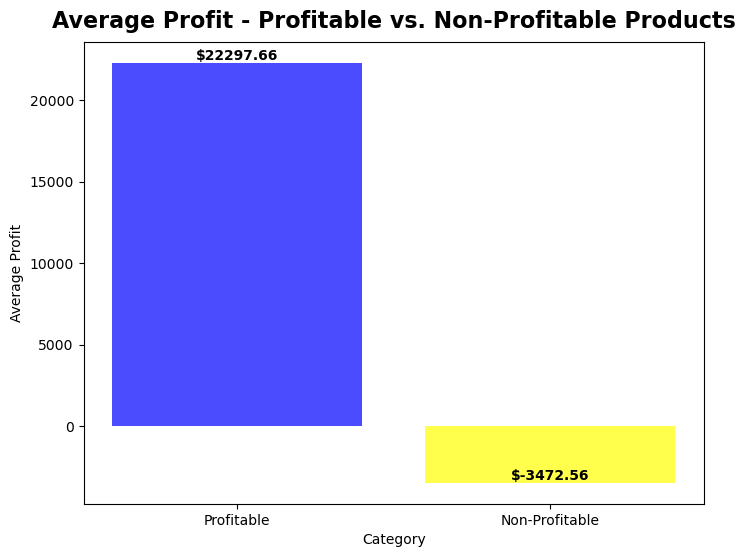

In [45]:

profitable_mean = profitable_stats['mean']
non_profitable_mean = non_profitable_stats['mean']

# Plotting the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(['Profitable', 'Non-Profitable'], [profitable_mean, non_profitable_mean],
               color=['blue', 'yellow'], alpha=0.7)

plt.title('Average Profit - Profitable vs. Non-Profitable Products', size=16, pad=10, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Average Profit')

# Adding annotations with dollar signs to the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'${height:.2f}',
             ha='center', va='bottom', fontweight='bold', color='black')

plt.show()

#### **Insight**

1. **Produk Menguntungkan vs Tidak Menguntungkan:** Grafik membandingkan rata-rata profit antara produk yang menguntungkan dan yang tidak menguntungkan.

2. **Produk Menguntungkan:** Produk yang menguntungkan memiliki rata-rata profit sebesar **\$22.297,66**.

3. **Produk Tidak Menguntungkan:** Produk yang tidak menguntungkan menghasilkan **rata-rata kerugian sebesar \$3.472,56**.

Analisis ini menunjukkan bahwa terdapat perbedaan yang signifikan dalam **rata-rata profit** antara produk yang menguntungkan dan yang tidak menguntungkan.


## **Choosing the Products which have negative profit values (Marketing Suite)**


In [46]:
df_msuite = df[df["Product"] == "Marketing Suite"]

# Display the updated DataFrame
df_msuite.head()

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Profit Margin
0,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,16.00
27,EMEA-2021-150630,2021-09-17,Neil Gill,France,Paris,EMEA,EU-WEST,Intel,1051,Tech,SMB,Marketing Suite,F8G07TWQ17,3083.4300,7,0.50,-1665.0522,-54.00
38,APJ-2021-117415,2021-12-27,Jasmine Metcalfe,Japan,Tokyo,APJ,JAPN,Banco Santander,1101,Finance,Enterprise,Marketing Suite,FBXEM82WEZ,532.3992,3,0.32,-46.9764,-8.82
189,EMEA-2021-102281,2021-10-12,Dylan Ogden,United Kingdom,London,EMEA,UKIR,HonHai Precision Industry,1033,Tech,Enterprise,Marketing Suite,7LL8W4OBLM,899.1360,4,0.20,112.3920,12.50
192,EMEA-2021-102281,2021-10-12,Dylan Ogden,United Kingdom,London,EMEA,UKIR,HonHai Precision Industry,1033,Tech,Enterprise,Marketing Suite,L0NREOWV2Y,626.3520,3,0.20,46.9764,7.50


## **Sales Trend**

Tren penjualan mengacu pada pergerakan keseluruhan angka penjualan dalam jangka waktu tertentu, apakah mengalami peningkatan, penurunan, atau tetap stabil. Menganalisis tren penjualan membantu dalam memahami kinerja suatu produk, layanan, atau bisnis dari waktu ke waktu.

**Alasan saya menggunakan median dalam analisis data ini adalah karena median tidak terpengaruh oleh outlier, dan dalam proses pembersihan data saya tidak menghapus outlier untuk melihat potensi penyebab profit negatif.**

1. **Tahan Terhadap Outlier:** Median adalah statistik yang kuat dan tidak terpengaruh oleh nilai ekstrem atau outlier. Sebaliknya, rata-rata (mean) sangat sensitif terhadap outlier. Jika data penjualan mengandung nilai ekstrem, maka median memberikan ukuran tendensi sentral yang lebih akurat.

2. **Data Miring (Skewed):** Jika data bersifat miring, median sering kali menjadi ukuran tendensi sentral yang lebih baik dibandingkan rata-rata. Rata-rata dapat tertarik ke arah kemiringan data, sedangkan median tidak.

3. **Mudah Dipahami:** Median merepresentasikan titik tengah dari data, yang berarti separuh nilai berada di atasnya dan separuh lainnya di bawah. Ini sering kali lebih intuitif dan bermakna, terutama saat menganalisis angka seperti penjualan.


#### **1. Penjualan Bulanan**


In [47]:
df_msuite = df_msuite.copy()
# Convert 'Order Date' to datetime if it's not already in datetime format
df_msuite['Order Date'] = pd.to_datetime(df['Order Date'])

# Extracting month and year
df_msuite['Order Month'] = df_msuite['Order Date'].dt.to_period('M')
df_msuite['Order Year'] = df_msuite['Order Date'].dt.to_period('Y')

# Displaying the updated DataFrame
df_msuite.head()

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Profit Margin,Order Month,Order Year
0,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,16.00,2022-11,2022
27,EMEA-2021-150630,2021-09-17,Neil Gill,France,Paris,EMEA,EU-WEST,Intel,1051,Tech,SMB,Marketing Suite,F8G07TWQ17,3083.4300,7,0.50,-1665.0522,-54.00,2021-09,2021
38,APJ-2021-117415,2021-12-27,Jasmine Metcalfe,Japan,Tokyo,APJ,JAPN,Banco Santander,1101,Finance,Enterprise,Marketing Suite,FBXEM82WEZ,532.3992,3,0.32,-46.9764,-8.82,2021-12,2021
189,EMEA-2021-102281,2021-10-12,Dylan Ogden,United Kingdom,London,EMEA,UKIR,HonHai Precision Industry,1033,Tech,Enterprise,Marketing Suite,7LL8W4OBLM,899.1360,4,0.20,112.3920,12.50,2021-10,2021
192,EMEA-2021-102281,2021-10-12,Dylan Ogden,United Kingdom,London,EMEA,UKIR,HonHai Precision Industry,1033,Tech,Enterprise,Marketing Suite,L0NREOWV2Y,626.3520,3,0.20,46.9764,7.50,2021-10,2021


In [48]:
df_sales = df_msuite.groupby('Order Month')[["Sales"]].median().reset_index()
df_sales['Sales'] = df_sales['Sales'].map('${:,.2f}'.format)

df_sales.head()


,Order Month,Sales
0,2020-01,$161.72
1,2020-02,$290.67
2,2020-03,$302.45
3,2020-04,$308.50
4,2020-05,$320.32


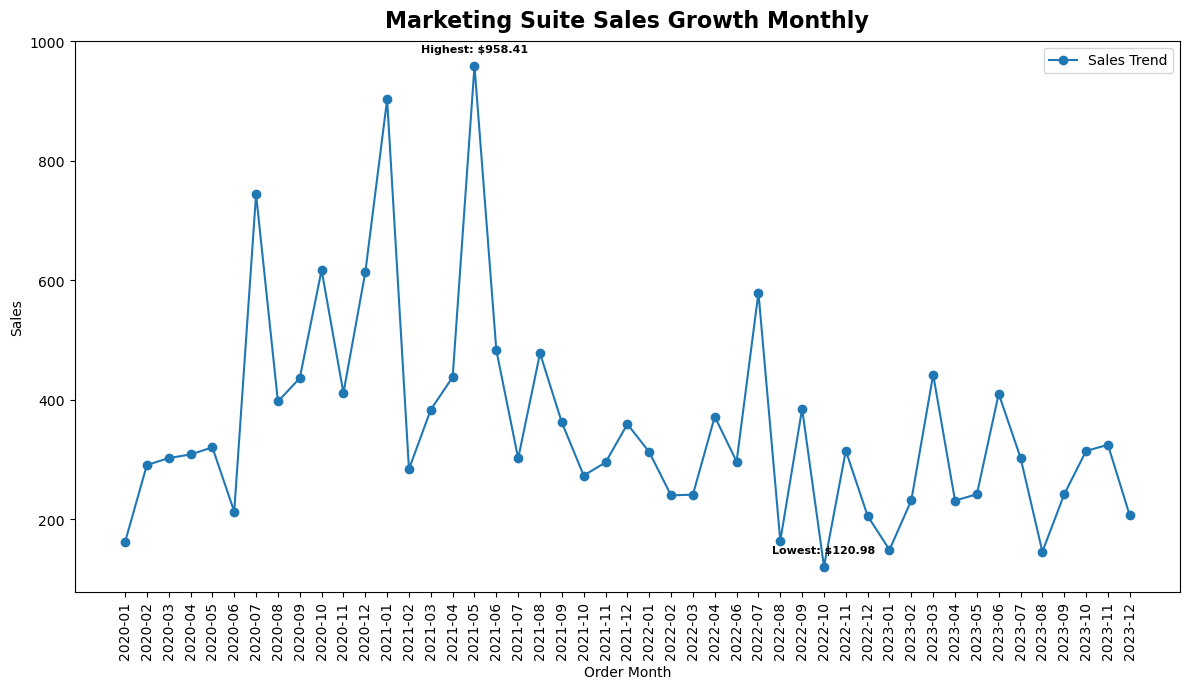

In [49]:
plt.figure(figsize=(12, 7))
sales_values = df_sales['Sales'].str.replace('$', '').astype(float)
plt.plot(df_sales['Order Month'].astype(str), sales_values, marker='o', linestyle='-', label='Sales Trend')

# Finding the index of the highest and lowest values
max_index = sales_values.idxmax()
min_index = sales_values.idxmin()

# Annotating the highest and lowest values with a cleaner format
plt.annotate(f"Highest: {df_sales['Sales'][max_index]}", 
             (df_sales['Order Month'].astype(str)[max_index], sales_values[max_index]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold')
plt.annotate(f"Lowest: {df_sales['Sales'][min_index]}", 
             (df_sales['Order Month'].astype(str)[min_index], sales_values[min_index]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold')

plt.xlabel('Order Month')
plt.ylabel('Sales')
plt.title('Marketing Suite Sales Growth Monthly', size=16, pad=10, fontweight='bold')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

plt.show()


#### **Insight**

1. **Fluktuasi Penjualan:** Angka penjualan mengalami fluktuasi yang signifikan sepanjang periode dari Januari 2020 hingga Desember 2023. Hal ini bisa disebabkan oleh berbagai faktor seperti tren musiman, kampanye pemasaran, atau perubahan kondisi pasar.

2. **Puncak Penjualan Tertinggi:** Penjualan tertinggi tercatat sebesar **\$958,41** pada bulan **Mei 2021**. Ini bisa menunjukkan keberhasilan strategi penjualan atau musim belanja yang ramai.

3. **Penjualan Terendah:** Penjualan terendah terjadi pada bulan **Oktober 2022** dengan angka sebesar **\$120,98**. Hal ini bisa menandakan periode penjualan yang lambat atau perlunya peningkatan upaya pemasaran pada waktu tersebut.

4. **Tren Terkini:** Dalam beberapa bulan terakhir di tahun **2023**, penjualan tampak relatif stabil, dengan kisaran angka antara **\$200 hingga \$400**. Namun, terdapat penurunan mencolok pada bulan **Agustus 2023** yang mungkin memerlukan investigasi lebih lanjut.


#### **2. Profit Bulanan**


In [50]:
df_profit = df_msuite.groupby("Order Month")[["Profit"]].median().reset_index()
df_profit['Profit'] = df_profit['Profit'].map('${:,.2f}'.format)

df_profit.head()


,Order Month,Profit
0,2020-01,$-24.68
1,2020-02,$3.42
2,2020-03,$-12.10
3,2020-04,$-18.15
4,2020-05,$-94.81


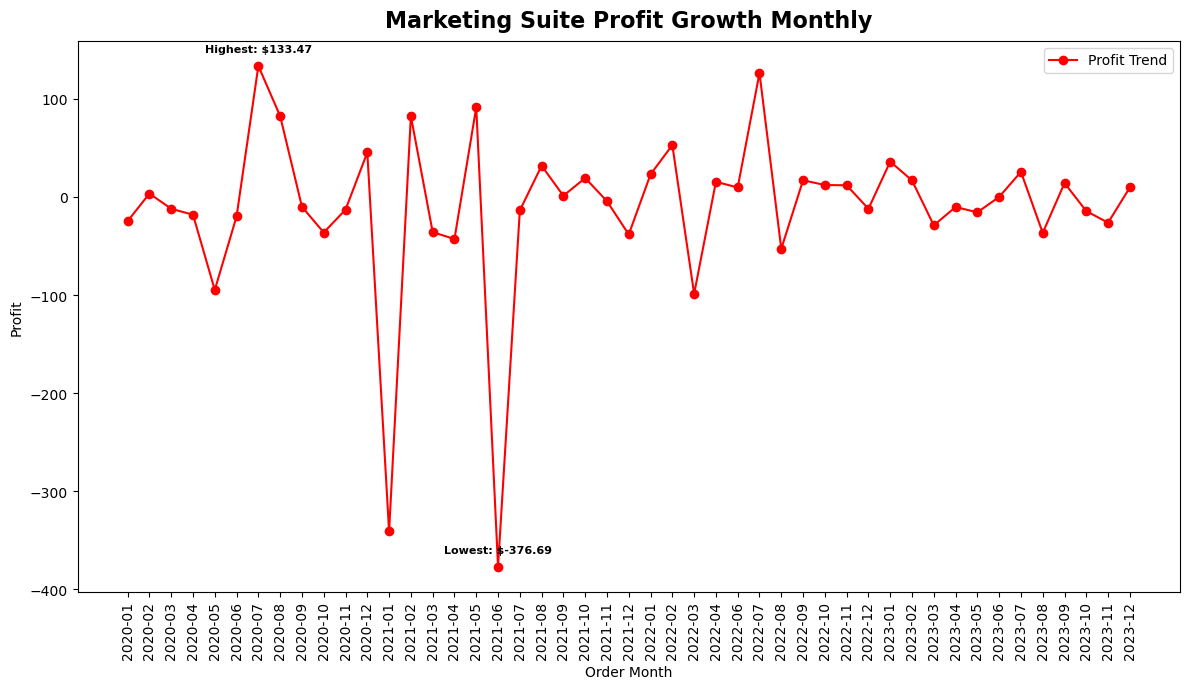

In [51]:
plt.figure(figsize=(12, 7))
profit_values = df_profit['Profit'].str.replace('$', '').astype(float)
plt.plot(df_profit['Order Month'].astype(str), profit_values, marker='o', linestyle='-', color='red', label='Profit Trend')

# Finding the index of the highest and lowest values
max_index = profit_values.idxmax()
min_index = profit_values.idxmin()

# Annotating the highest and lowest values with a cleaner format
plt.annotate(f"Highest: {df_profit['Profit'][max_index]}", 
             (df_profit['Order Month'].astype(str)[max_index], profit_values[max_index]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold')
plt.annotate(f"Lowest: {df_profit['Profit'][min_index]}", 
             (df_profit['Order Month'].astype(str)[min_index], profit_values[min_index]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold')

plt.xlabel('Order Month')
plt.ylabel('Profit')
plt.title('Marketing Suite Profit Growth Monthly', size=16, pad=10, fontweight='bold')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

plt.show()

#### **Insight**

1. **Fluktuasi Profit:** Angka profit mengalami fluktuasi yang signifikan sepanjang periode dari **Januari 2020 hingga Desember 2023**. Hal ini bisa disebabkan oleh berbagai faktor seperti perubahan dalam penjualan, harga pokok penjualan, biaya operasional, atau biaya lainnya.

2. **Profit Tertinggi:** Profit tertinggi tercatat sebesar **\$133,47** pada bulan **Juli 2020**. Ini bisa menunjukkan keberhasilan strategi penjualan, efisiensi biaya, atau musim belanja yang menguntungkan.

3. **Profit Terendah:** Profit terendah berupa **kerugian sebesar \$376,69** terjadi pada bulan **Juni 2021**. Hal ini dapat mengindikasikan periode penjualan yang lambat, peningkatan biaya, atau perlunya strategi bisnis yang lebih baik pada saat itu.

4. **Tren Terkini:** Dalam beberapa bulan terakhir tahun **2023**, profit terlihat relatif stabil, dengan kisaran angka antara **-\$50 hingga \$50**. Namun, terdapat **penurunan mencolok pada bulan Agustus 2023**, yang mungkin perlu dilakukan investigasi lebih lanjut.


#### **3. Margin Profit Bulanan**


In [52]:
df_profit_margin = df_msuite.groupby("Order Month")[["Profit Margin"]].median().reset_index()
df_profit_margin['Profit Margin'] = df_profit_margin['Profit Margin'].apply(lambda x: f"{x:.2f}%")
df_profit_margin.head()


,Order Month,Profit Margin
0,2020-01,-42.41%
1,2020-02,1.18%
2,2020-03,-5.88%
3,2020-04,-5.88%
4,2020-05,-26.30%


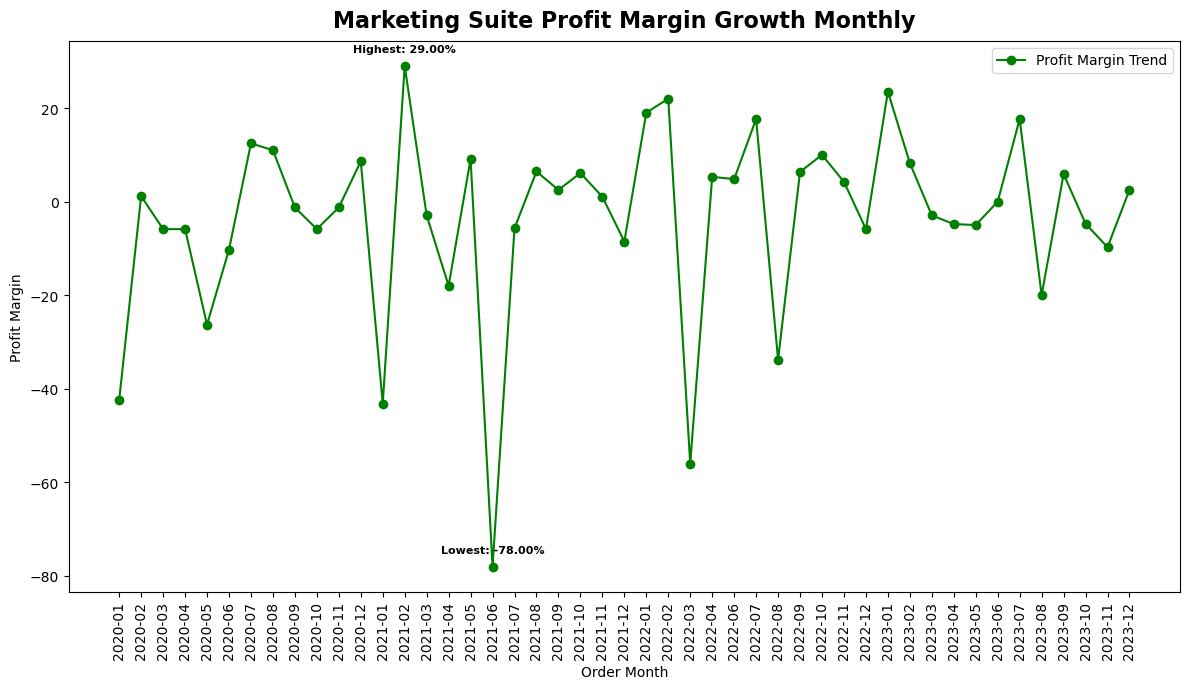

In [53]:
plt.figure(figsize=(12, 7))
profit_margin_values = df_profit_margin['Profit Margin'].str.rstrip('%').astype(float)  # Removing '%' symbol and converting to numeric
plt.plot(df_profit_margin['Order Month'].astype(str), profit_margin_values, marker='o', linestyle='-', color='green', label='Profit Margin Trend')

# Finding the index of the highest and lowest values
max_index = profit_margin_values.idxmax()
min_index = profit_margin_values.idxmin()

# Annotating the highest and lowest values with a cleaner format
plt.annotate(f"Highest: {df_profit_margin['Profit Margin'][max_index]}", 
             (df_profit_margin['Order Month'].astype(str)[max_index], profit_margin_values[max_index]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold')
plt.annotate(f"Lowest: {df_profit_margin['Profit Margin'][min_index]}", 
             (df_profit_margin['Order Month'].astype(str)[min_index], profit_margin_values[min_index]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold')

plt.xlabel('Order Month')
plt.ylabel('Profit Margin')
plt.title('Marketing Suite Profit Margin Growth Monthly', size=16, pad=10, fontweight='bold')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

plt.show()

#### **Insight**

1. **Fluktuasi Margin Profit:** Angka margin profit mengalami fluktuasi yang signifikan sepanjang periode dari **Januari 2020 hingga Desember 2023**. Hal ini bisa disebabkan oleh berbagai faktor seperti perubahan penjualan, harga pokok penjualan, biaya operasional, atau biaya lainnya.

2. **Margin Profit Tertinggi:** Margin profit tertinggi tercatat sebesar **29,00%** pada bulan **Februari 2021**. Ini bisa menunjukkan keberhasilan strategi penjualan, efisiensi biaya, atau musim belanja yang menguntungkan.

3. **Margin Profit Terendah:** Margin profit terendah berupa **kerugian sebesar 78,00%** terjadi pada bulan **Juni 2021**. Hal ini dapat mengindikasikan periode penjualan yang lambat, peningkatan biaya, atau perlunya strategi bisnis yang lebih baik pada saat itu.

4. **Tren Terkini:** Dalam beberapa bulan terakhir di tahun **2023**, margin profit tampak relatif stabil, dengan kisaran angka antara **-10% hingga 20%**. Namun, terdapat **penurunan mencolok pada bulan Agustus 2023** yang mungkin memerlukan investigasi lebih lanjut.


#### **4. Diskon Bulanan**


In [54]:
df_discount = df_msuite.groupby("Order Month")[["Discount"]].median().reset_index()
df_discount['Discount'] = (df_discount['Discount'] * 100).apply(lambda x: f"{x:.2f}%")
df_discount.head()

,Order Month,Discount
0,2020-01,32.50%
1,2020-02,15.00%
2,2020-03,15.00%
3,2020-04,15.00%
4,2020-05,32.50%


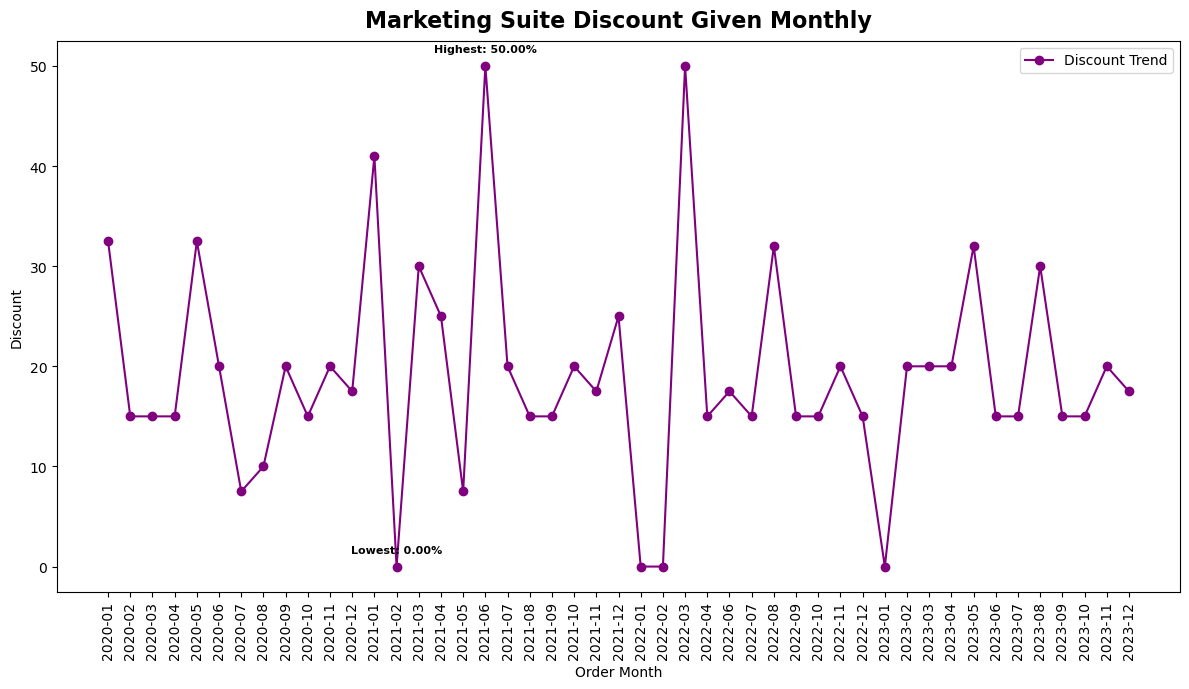

In [55]:
plt.figure(figsize=(12, 7))
discount_values = df_discount['Discount'].str.replace('%', '').astype(float)
plt.plot(df_discount['Order Month'].astype(str), discount_values, marker='o', linestyle='-', color='purple', label='Discount Trend')

# Finding the index of the highest and lowest values
max_index = discount_values.idxmax()
min_index = discount_values.idxmin()

# Annotating the highest and lowest values with a cleaner format
plt.annotate(f"Highest: {df_discount['Discount'][max_index]}", 
             (df_discount['Order Month'].astype(str)[max_index], discount_values[max_index]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold')
plt.annotate(f"Lowest: {df_discount['Discount'][min_index]}", 
             (df_discount['Order Month'].astype(str)[min_index], discount_values[min_index]),
             textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold')

plt.xlabel('Order Month')
plt.ylabel('Discount')
plt.title('Marketing Suite Discount Given Monthly', size=16, pad=10, fontweight='bold')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

plt.show()

#### **Insight**

1. **Variasi Diskon:** Besaran diskon yang diberikan sangat bervariasi setiap bulannya, dengan yang tertinggi mencapai **50,00%** dan yang terendah **0,00%**. Tidak terlihat adanya tren yang jelas dalam tingkat diskon; nilainya berfluktuasi dari bulan ke bulan.

2. **Diskon Tertinggi:** Diskon tertinggi sebesar **50,00%** diberikan pada bulan **Juni 2021** dan **Maret 2022**.

3. **Tanpa Diskon:** Tidak ada diskon (0,00%) yang diberikan pada bulan **Februari 2021**, **Januari 2022**, dan **Februari 2022**.

4. **Tren Terkini:** Dalam beberapa bulan terakhir tahun **2023**, diskon yang diberikan berada di kisaran **15,00% hingga 32,00%**, dengan pengecualian pada bulan **Januari 2023** di mana tidak ada diskon yang diberikan.


## **Analisis Dampak Diskon terhadap Profitabilitas**


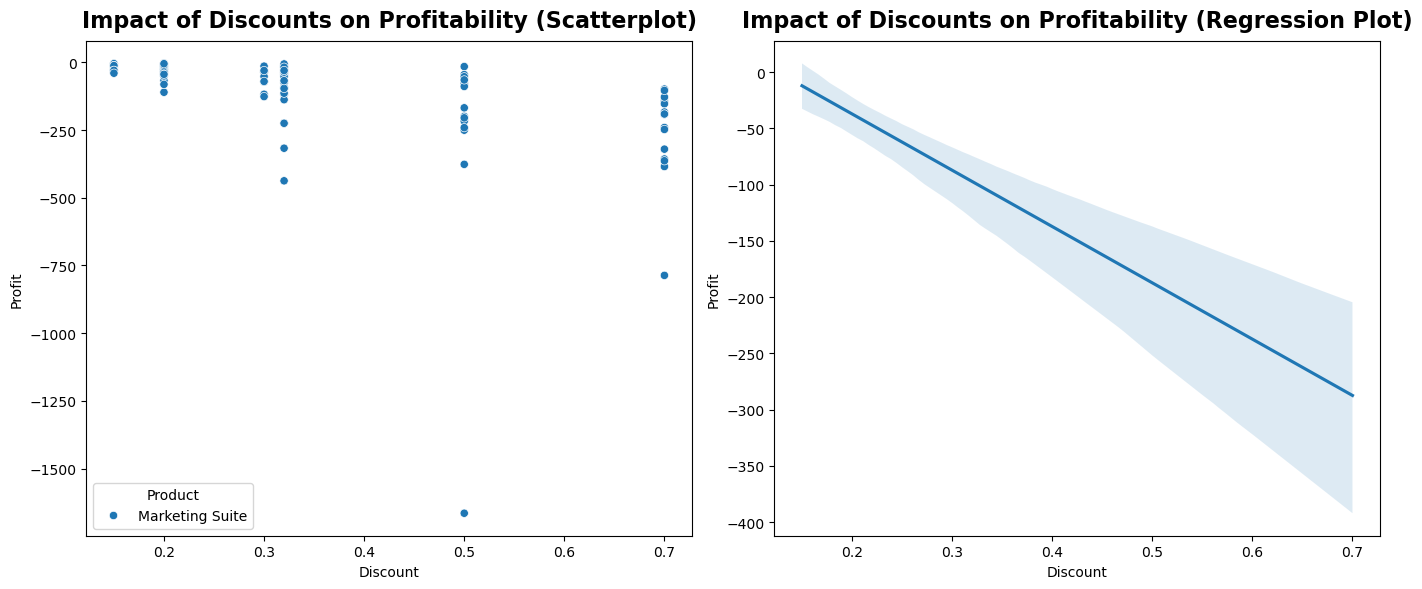

In [56]:
# Filter the DataFrame for products with negative profit
negative_profit_products = df_msuite[df_msuite['Profit'] < 0]

# Create subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Plotting scatterplot
sns.scatterplot(x='Discount', y='Profit', data=negative_profit_products, hue='Product', ax=ax1)
ax1.set_title('Impact of Discounts on Profitability (Scatterplot)', size=16, pad=10, fontweight='bold')
ax1.set_xlabel('Discount')
ax1.set_ylabel('Profit')
ax1.legend(title='Product')

# Plotting regression plot
sns.regplot(x='Discount', y='Profit', data=negative_profit_products, scatter=False, ax=ax2)
ax2.set_title('Impact of Discounts on Profitability (Regression Plot)', size=16, pad=10, fontweight='bold')
ax2.set_xlabel('Discount')
ax2.set_ylabel('Profit')

plt.tight_layout()
plt.show()


**Insight**

1. **Korelasi Negatif:** Kedua grafik menunjukkan adanya korelasi negatif antara diskon dan profitabilitas untuk produk **Marketing Suite**. Semakin besar diskon yang diberikan, semakin rendah profitabilitasnya.

2. **Scatterplot:** Grafik scatterplot di sebelah kiri menunjukkan profit pada berbagai tingkat diskon untuk **Marketing Suite** (berwarna biru). Baik pada level **Product** maupun **Marketing Suite**, terlihat penurunan profit seiring dengan meningkatnya diskon.

3. **Grafik Regresi:** Grafik regresi di sebelah kanan menunjukkan garis tren negatif yang jelas, yang mengindikasikan bahwa semakin besar diskon, semakin rendah profit yang diperoleh. Area berbayang menggambarkan **interval kepercayaan** di sekitar garis regresi.

**Insight ini menunjukkan bahwa peningkatan diskon dapat menyebabkan penurunan profitabilitas untuk produk Marketing Suite.**


In [57]:
df_region = df_msuite.groupby('Region')['Profit'].sum().sort_values(ascending=False)
df_region.head()

Region
AMER      52.7756
EMEA   -1629.6682
APJ    -1895.6634
Name: Profit, dtype: float64

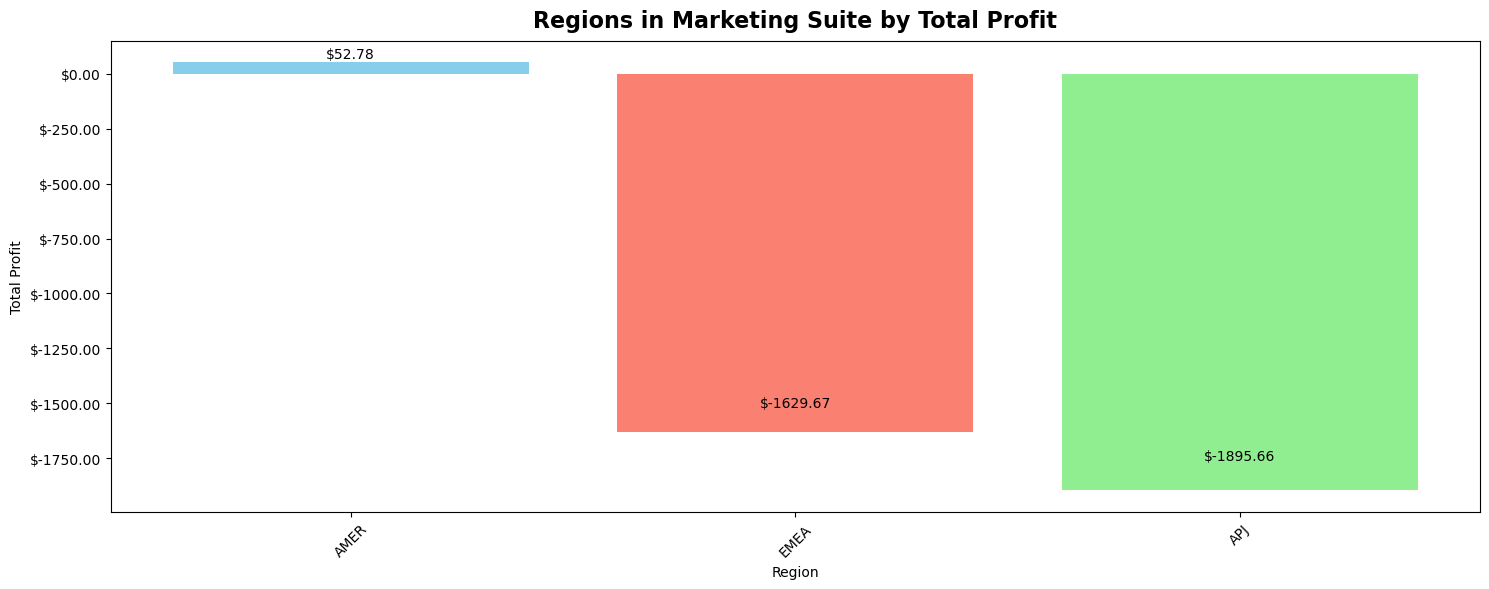

In [58]:

# Plotting with different colors for each bar and annotations
plt.figure(figsize=(15, 6))

# Custom colors for bars
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'lightcoral']

# Plotting each bar individually with different color and annotation
for i, (index, value) in enumerate(df_region.head().items()):
    plt.bar(index, value, color=colors[i])
    
    # Adjusting text position based on value sign
    text_position = value + 0.1 * value if value >= 0 else value - 0.1 * value
    plt.text(i, text_position, f'${value:.2f}', ha='center', va='bottom' if value >= 0 else 'top')

plt.title('Regions in Marketing Suite by Total Profit', size=16, pad=10, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)

# Formatting y-axis ticks to display '$' sign with values
plt.gca().yaxis.set_major_formatter('${:.2f}'.format)

plt.tight_layout()
plt.show()

In [59]:
df_Subregion = df_msuite.groupby('Subregion')['Profit'].sum().sort_values(ascending=True)
df_Subregion.head()

Subregion
EU-WEST   -3257.8735
JAPN      -2391.1377
EU-EAST   -2184.3301
LATAM     -1936.2213
ANZ        -555.8726
Name: Profit, dtype: float64

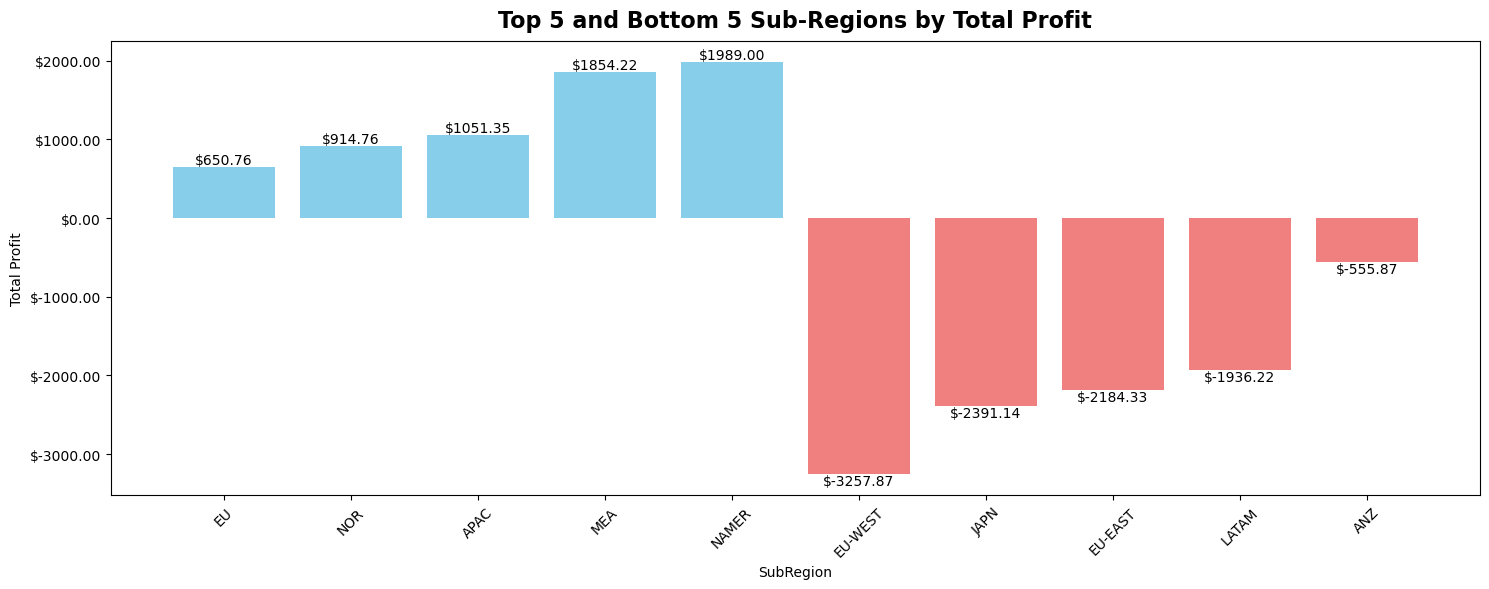

In [60]:
# Splitting into top 5 and bottom 5
top_5 = df_Subregion.tail(5)
bottom_5 = df_Subregion.head(5)

# Combining top and bottom 5 for plotting
combined_data = pd.concat([top_5, bottom_5])

# Plotting with different colors for each bar and annotations
plt.figure(figsize=(15, 6))

# Custom colors for bars
colors = ['skyblue'] * 5 + ['lightcoral'] * 5  # Assigning colors for top and bottom separately

# Plotting each bar individually with different color and annotation
for i, (index, value) in enumerate(combined_data.items()):
    plt.bar(index, value, color=colors[i])
    
    # Adjusting text position to center the annotation
    plt.text(i, value, f'${value:.2f}', ha='center', va='bottom' if value >= 0 else 'top')

plt.title('Top 5 and Bottom 5 Sub-Regions by Total Profit', size=16, pad=10, fontweight='bold')
plt.xlabel('SubRegion')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)

# Formatting y-axis ticks to display '$' sign with values
plt.gca().yaxis.set_major_formatter('${:.2f}'.format)

plt.tight_layout()
plt.show()

In [61]:

df_Country = df_msuite.groupby('Country')['Profit'].sum().sort_values(ascending=True)

# Convert the Series to a DataFrame
df_Country = pd.DataFrame(df_Country).reset_index()

# Display the first few rows
df_Country

,Country,Profit
0,France,-2896.7601
1,Russia,-2408.9163
2,Japan,-2391.1377
3,Mexico,-1359.0516
4,Chile,-869.2073
5,Belgium,-616.8158
6,Australia,-555.8726
7,Germany,-116.0706
8,Sweden,-97.9780
9,South Africa,-6.3236


## **Visualisasi Folium untuk Negara yang Memiliki Profit Negatif dan Positif pada Marketing Suite**


In [62]:
df_Country_geo = df_Country.merge(df_coords, on='Country', how='left')


In [63]:
df_Country_geo_clean = df_Country_geo.dropna(subset=['Latitude', 'Longitude'])


In [64]:
import folium

center_lat = df_Country_geo_clean['Latitude'].iloc[0]
center_lon = df_Country_geo_clean['Longitude'].iloc[0]
world_map = folium.Map(location=[center_lat, center_lon], zoom_start=3)

for i, row in df_Country_geo_clean.iterrows():
    profit = row['Profit']
    country = row['Country']
    lat = row['Latitude']
    lon = row['Longitude']
    marker_color = 'red' if profit < 0 else 'blue'
    folium.Marker(
        location=[lat, lon],
        popup=f"{country} | Profit: ${profit:.2f}",
        tooltip=country,
        icon=folium.Icon(color=marker_color)
    ).add_to(world_map)

world_map


**Insight**

1. Negara-negara yang memperoleh profit adalah Kanada, El Sav, Finlandia, Mesir, dan Amerika Serikat dengan profit masing-masing sebesar \$570,01, \$650,76, \$883,26, \$1.013,13, dan \$1.418,99.

2. Negara-negara yang mengalami kerugian adalah Prancis, Rusia, Jepang, Meksiko, dan Chili dengan kerugian masing-masing sebesar -\$869,21, -\$1.359,05, -\$2.408,92, -\$2.391,14, dan -\$2.896.

3. Amerika Serikat mencatat profit tertinggi, sedangkan Chili mencatat kerugian terbesar.

**Data ini menunjukkan bahwa produk marketing suite berjalan baik di Kanada, El Sav, Finlandia, Mesir, dan Amerika Serikat, namun menghadapi tantangan di Prancis, Rusia, Jepang, Meksiko, dan Chili. Strategi di negara-negara tersebut mungkin perlu dievaluasi ulang untuk meningkatkan performa.**


## **Total Profit Marketing Suite berdasarkan Kota**


In [65]:
df_City = df_msuite.groupby('City')['Profit'].sum().sort_values(ascending=True)
df_City.head()

City
Paris           -2568.1413
St Petersburg   -1331.3179
Tokyo           -1120.4223
Mexico City      -884.9520
Moscow           -653.1820
Name: Profit, dtype: float64

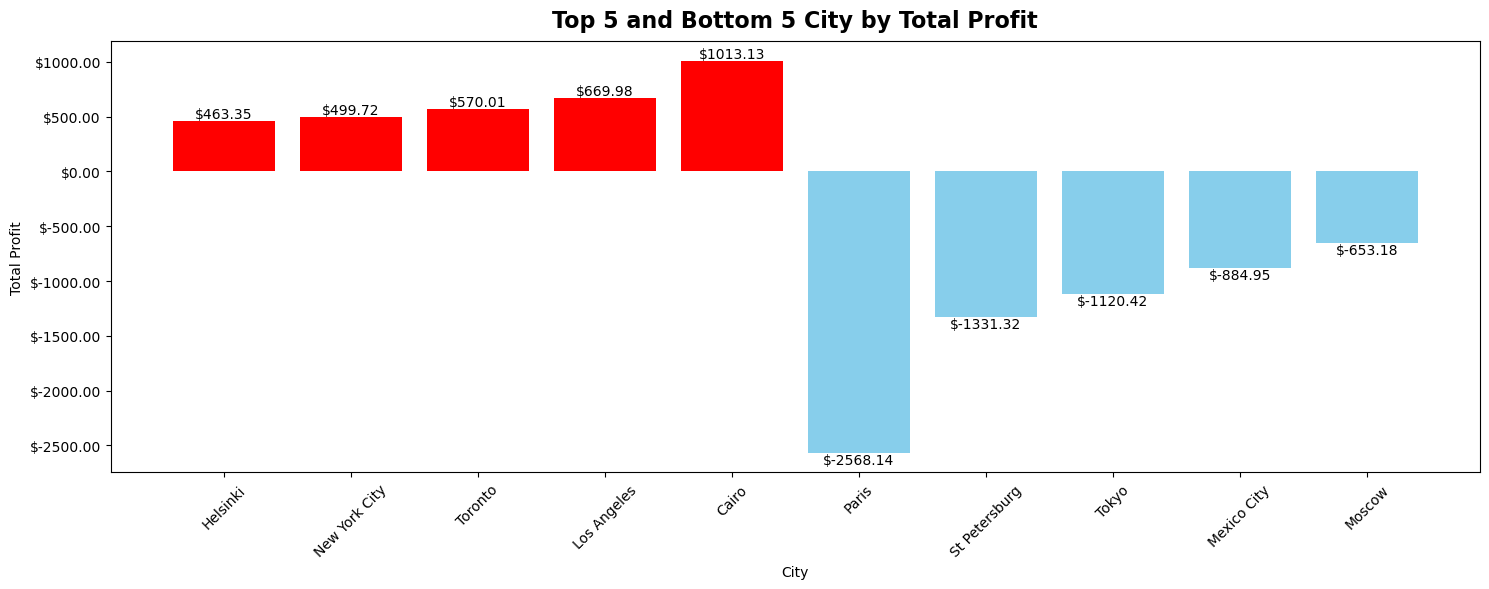

In [66]:
# Splitting into top 5 and bottom 5
top_5 = df_City.tail(5)
bottom_5 = df_City.head(5)

# Combining top and bottom 5 for plotting
combined_data = pd.concat([top_5, bottom_5])

# Plotting with different colors for each bar and annotations
plt.figure(figsize=(15, 6))

# Custom colors for bars
colors = ['red'] * 5 + ['skyblue'] * 5  # Assigning colors for top and bottom separately

# Plotting each bar individually with different color and annotation
for i, (index, value) in enumerate(combined_data.items()):
    plt.bar(index, value, color=colors[i])
    
    # Adjusting text position to center the annotation
    plt.text(i, value, f'${value:.2f}', ha='center', va='bottom' if value >= 0 else 'top')

plt.title('Top 5 and Bottom 5 City by Total Profit', size=16, pad=10, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)

# Formatting y-axis ticks to display '$' sign with values
plt.gca().yaxis.set_major_formatter('${:.2f}'.format)

plt.tight_layout()
plt.show()

**Insight**

1. The profitable cities are Helsinki, New York City, Toronto, Los Angeles, and Cairo with profits of $463.35, $499.72, $570.01, $669.98, and $1013.13 respectively.

2. The unprofitable cities are Paris, St. Petersburg, Tokyo, Mexico City, and Moscow with losses of -$2568.14, -$1331.32, -$1120.42, -$884.95, and -$653.18 respectively.

3. Cairo has the highest profit, while Paris has the highest loss.

**This data suggests that the marketing suite product is performing well in Helsinki, New York City, Toronto, Los Angeles, and Cairo but is facing challenges in Paris, St. Petersburg, Tokyo, Mexico City, and Moscow.**


## **Frekuensi Pembelian oleh Pelanggan pada Marketing Suite**


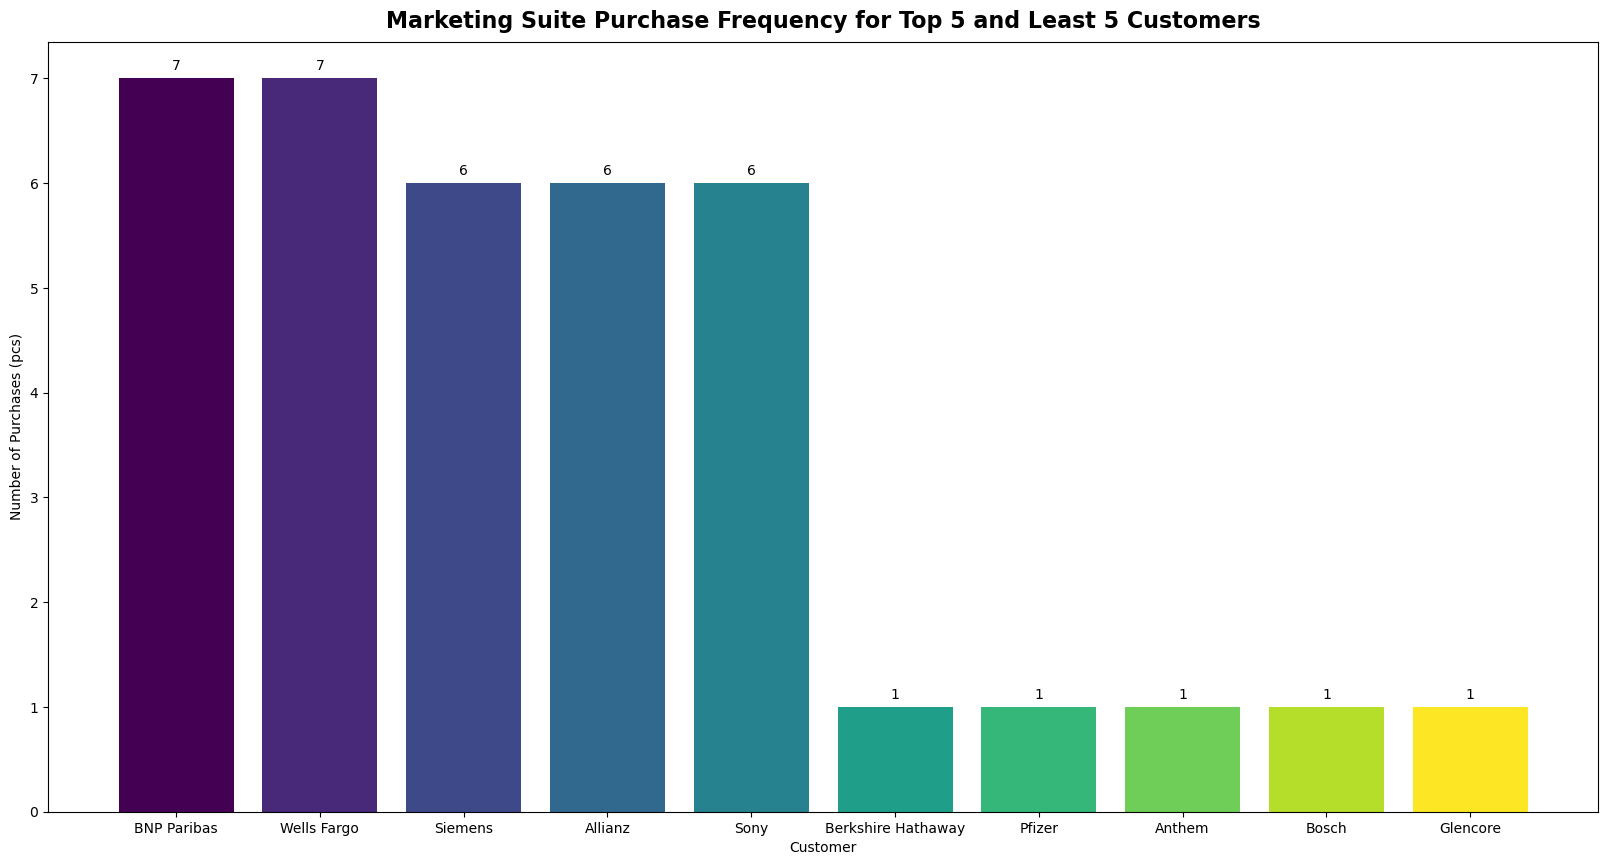

In [67]:
# Get top 5 customers
top_5_customers = df_msuite['Customer'].value_counts().nlargest(5)

# Get least 5 customers
least_5_customers = df_msuite['Customer'].value_counts().nsmallest(5)

# Concatenate the two series
selected_customers = pd.concat([top_5_customers, least_5_customers])

# Create a bar plot
plt.figure(figsize=(20,10))

# Generate random colors
colors = plt.cm.viridis(np.linspace(0, 1, len(selected_customers)))

# Plot the data
bars = plt.bar(selected_customers.index, selected_customers, color=colors)

plt.title('Marketing Suite Purchase Frequency for Top 5 and Least 5 Customers',size=16, pad=10, fontweight='bold')
plt.xlabel('Customer')
plt.ylabel('Number of Purchases (pcs)')

# Add annotations
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 2), ha='center', va='bottom')

plt.show()


**Insight**

1. Customer Purchase Frequency: BNP Paribas and Wells Fargo are your most frequent customers for the marketing suite product. It might be beneficial to understand why they are making frequent purchases despite the product’s negative profit.

2. Low Purchase Frequency: The customers with low purchase frequency (Berkshire Hathaway Customer, Pfizer, Anthem, Bosch, and Glencore) might need more engagement or targeted marketing to increase their usage of the marketing suite product.

3. Product Profitability: If the marketing suite product is consistently generating negative profit, it might be worth conducting a thorough cost-benefit analysis. Understanding the product’s cost structure and its perceived value to customers could provide insights into whether its pricing strategy needs adjustment


## **Correlation Analysis**


,Sales,Discount,Profit,Profit Margin,Quantity
Sales,1.000000,-0.149500,0.233466,0.165776,0.617434
Discount,-0.149500,1.000000,-0.831739,-0.892099,0.144368
Profit,0.233466,-0.831739,1.000000,0.929936,-0.052914
Profit Margin,0.165776,-0.892099,0.929936,1.000000,-0.117881
Quantity,0.617434,0.144368,-0.052914,-0.117881,1.000000


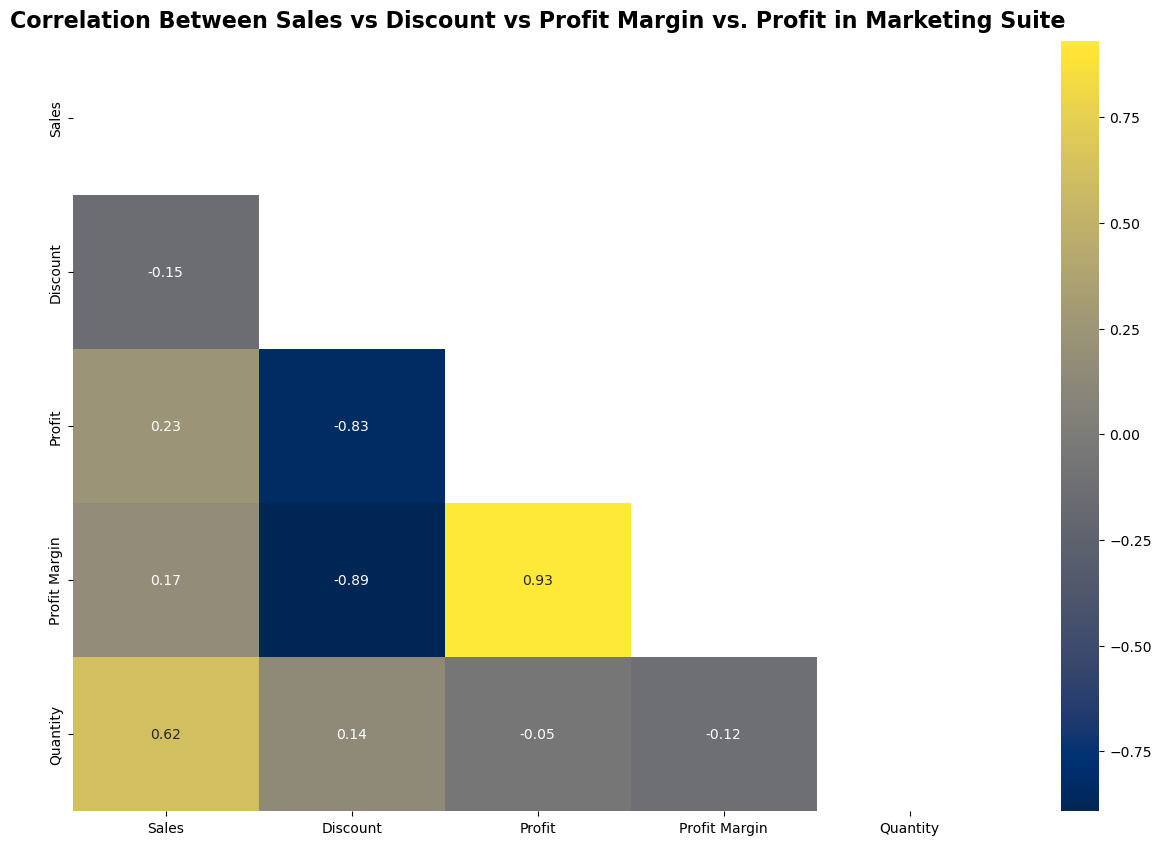

In [68]:
numerical_col = ["Sales", "Discount", "Profit", "Profit Margin",'Quantity']
correlation = df_msuite[numerical_col].corr(method = "spearman")
matriks = np.triu(correlation)
display(correlation)

plt.figure(figsize = (15, 10))
sns.heatmap(
    data = correlation,
    annot = True,
    fmt = ".2f",
    cmap = "cividis",
    center = 0,
    mask = matriks
)

plt.title("Correlation Between Sales vs Discount vs Profit Margin vs. Profit in Marketing Suite", size=16, pad=10, fontweight='bold')
plt.show()

In [69]:
numerical_col = ["Sales", "Discount", "Profit", "Profit Margin",'Quantity']

for col in numerical_col:
    corr = df_msuite[col].corr(df["Profit"], method="spearman")

    if corr > 0:
        correlation = "positive"
        if  corr > 0.0 and corr <= 0.2:
            strength = "very weak"
        elif corr > 0.2 and corr <= 0.4:
            strength = "weak"    
        elif corr > 0.4 and corr <= 0.6:
            strength = "moderate"
        elif corr > 0.6 and corr <= 0.9:
            strength = "strong"
        else:
            strength = "very strong"
    else:
        correlation = "negative"
        if corr  < 0.0 and corr >= -0.2:
            strength = "very weak"
        elif corr < -0.2 and corr >= -0.4:
            strength = "weak"    
        elif corr < -0.4 and corr >= -0.6:
            strength = "moderate"
        elif corr < -0.6 and corr >= -0.9:
            strength = "strong"
        else:
            strength = "very strong"

    print(f"The correlation value between the {col} and Profit columns is {corr:.2f}")
    print(f"The relationship between the {col} and Profit variables is '{correlation}' with a correlation strength of '{strength}'.")
    print()


The correlation value between the Sales and Profit columns is 0.23
The relationship between the Sales and Profit variables is 'positive' with a correlation strength of 'weak'.

The correlation value between the Discount and Profit columns is -0.83
The relationship between the Discount and Profit variables is 'negative' with a correlation strength of 'strong'.

The correlation value between the Profit and Profit columns is 1.00
The relationship between the Profit and Profit variables is 'positive' with a correlation strength of 'very strong'.

The correlation value between the Profit Margin and Profit columns is 0.93
The relationship between the Profit Margin and Profit variables is 'positive' with a correlation strength of 'very strong'.

The correlation value between the Quantity and Profit columns is -0.05
The relationship between the Quantity and Profit variables is 'negative' with a correlation strength of 'very weak'.



**Insight**

1. Profit memiliki hubungan positif yang kuat dengan Profit Margin. Artinya, semakin tinggi Profit yang didapatkan, semakin tinggi pula persentase Profit Margin yang diterima.

2. Sales memiliki hubungan positif yang lemah dengan Profit dan Profit Margin. Ini berarti ketika Sales meningkat, nilai dan persentase Profit serta Profit Margin juga ikut naik.

3. Sales memiliki hubungan negatif yang lemah dengan Discount. Hal ini menunjukkan bahwa ketika Sales menurun, biasanya disebabkan oleh meningkatnya Discount.

4. Discount memiliki hubungan negatif yang kuat dengan Profit dan Profit Margin. Ini menandakan bahwa ketika nilai Discount tinggi, Profit dan Profit Margin mengalami penurunan yang drastis.

5. Quantity memiliki hubungan negatif yang lemah dengan Profit dan Profit Margin. Ini mengindikasikan bahwa ketika Quantity meningkat, hal ini menyebabkan penurunan Profit dan Profit Margin yang diperoleh perusahaan.

**Kesimpulan**

Grafik heatmap memberikan insight yang sangat berguna mengenai hubungan antar variabel dalam Marketing Suite.
Grafik ini menunjukkan bagaimana Profit, Sales, Discount, dan Profit Margin saling berinteraksi. Misalnya, **meskipun diskon dapat meningkatkan penjualan, ternyata diskon juga memberikan dampak negatif yang signifikan terhadap profit dan profit margin**. Oleh karena itu, strategi diskon sebaiknya ditinjau kembali agar tidak menggerus keuntungan. Demikian pula, strategi yang meningkatkan penjualan terbukti berdampak positif pada profit dan profit margin, sehingga layak untuk dioptimalkan lebih lanjut.


# **Finalization**

## **Kesimpulan**

Produk Marketing Suite di perusahaan AWS SaaS secara konsisten menunjukkan margin profit yang negatif sepanjang periode analisis. Produk ini menjadi faktor utama yang menurunkan profitabilitas keseluruhan lini produk perusahaan. Tren profit yang negatif ini menunjukkan perlunya perhatian segera dan intervensi strategis.

Produk Marketing Suite secara konsisten memperlihatkan tren profitabilitas negatif di berbagai dimensi analisis. Dari analisis korelasi, regional, sub-regional, negara, hingga kota, terlihat jelas bahwa Marketing Suite menghadapi tantangan besar di wilayah, dan sub-wilayah tertentu.


## Insight untuk Marketing Suite

1. **Korelasi Diskon-Profit:** Terdapat korelasi negatif yang jelas antara diskon dan profitabilitas pada Marketing Suite. Peningkatan diskon berbanding lurus dengan penurunan profitabilitas, sehingga strategi diskon perlu dievaluasi kembali.

2. **Analisis Regional:** Marketing Suite menunjukkan performa baik di beberapa wilayah seperti AMER, namun kesulitan di wilayah seperti EMEA dan APJ. Hal ini menandakan perlunya strategi yang disesuaikan di wilayah-wilayah yang belum optimal.

3. **Tren Sub-Regional dan Negara:** Profitabilitas bervariasi antar sub-wilayah dan negara. Beberapa area menghasilkan profit, sementara area lain mengalami kerugian signifikan. Contohnya, Kanada dan Mesir mencatat profit, sedangkan Prancis dan Jepang mengalami kerugian besar.

4. **Performa di Tingkat Kota:** Beberapa kota menunjukkan profit positif untuk Marketing Suite, seperti Helsinki dan New York City, sedangkan kota seperti Paris dan Tokyo mencatat kerugian yang cukup besar.


## Rekomendasi untuk Marketing Suite

**1. Strategi Mitigasi Kerugian:**

* Analisis lebih lanjut faktor-faktor yang menyebabkan kerugian pada pelanggan tertentu agar dapat merancang strategi perbaikan yang lebih terarah, atau jika perlu, pertimbangkan kembali hubungan bisnis dengan pelanggan tersebut.

**2. Strategi Penetapan Harga dan Analisis Cost-Benefit:**

* Lakukan analisis cost-benefit yang mendalam pada Marketing Suite untuk memahami struktur biaya dan nilai yang dirasakan pelanggan. Ini akan membantu menilai apakah strategi harga saat ini sudah sesuai dengan ekspektasi pelanggan dan kondisi pasar.

**3. Optimasi Strategi Diskon:**

* Tinjau dan optimalkan kembali strategi diskon untuk menyeimbangkan antara peningkatan penjualan dan menjaga margin keuntungan. Pertimbangkan pemberian diskon bertingkat atau penawaran bersyarat untuk menjaga profitabilitas.

**4. Inisiatif yang Berfokus pada Penjualan:**

* Investasikan strategi yang dapat meningkatkan penjualan tanpa terlalu bergantung pada diskon. Berdasarkan hubungan positif yang lemah antara penjualan dan profit/margin profit, strategi semacam ini berpotensi meningkatkan profitabilitas tanpa harus mengorbankan margin melalui diskon yang berlebihan.
